# Appendix E: the same model, implemented locally

**Read this after `main.ipynb`, not instead of it.** Nothing here changes a prediction, a
fixed point, a learned parameter or a figure. Code Cell E3 checks that claim against the output
`main.ipynb` recorded, line by line, rather than asserting it.

**What is outstanding in `main.ipynb`.** Text cell 3 §7 writes the plasticity rule for
$\theta_u$ as $\tau_\theta\dot\theta_u=\varphi_u\langle\varepsilon_S,b\rangle$, one presynaptic
activity times one pooled error signal, and Appendix B defends that as Hebbian. The implementation
runs at $m=2$, where the same rule reads $\sum_j\varphi_{u,j}\langle\varepsilon_S,b_j\rangle$: a sum
of products formed at $m$ synapses on $m$ **different** neurons. Appendix B says as much, that being
the structure the constraint of local plasticity forbids. So `main.ipynb` makes its locality claim at
$m=1$, where the claim is clean, and Appendix C then shows that $m=1$ is degenerate. The claim is
made where the model does not run.

**What this appendix does.** It inserts one node, and resolves the violation by relocating the sum
rather than by changing the arithmetic.

The $m$ columns of $B$ become the fixed terminal fields of the $m$ $\varphi_u$ axons on a descending
relay, so relay node $k$ receives $\sum_j B_{kj}\varphi_{u,j}$ as its own afferent sum. The quantity
Eq. (B4) had to gather from $m$ neurons is therefore already formed, as the relay's activity
$r=B\varphi_u$, before the learning rule is consulted. $\theta_u$ becomes the gain of the single
projection from the relay to $\varepsilon_S$, and its update is $\langle\varepsilon_S,r\rangle$, with
$r$ presynaptic and $\varepsilon_S$ postsynaptic on that one projection.

The sum over $j$ is not removed. It is moved out of the plasticity rule, where a synapse would have
had to read activity on other neurons, and into a dendrite, where summing one's own afferents is
what local computation permits. What is left in the rule is pooling across the $K$ terminals of one
projection, at any $m$, which is exactly the pooling Appendix B already commits to and defends.

**Why it is a separate appendix rather than a correction.** The relay buys locality and nothing
else. It is the harder object to hold in mind on a first pass, and every number it produces is a
number `main.ipynb` already produced, so nothing in the main line of argument depends on
reading it. `main.ipynb` stands as written.

## E.1 The equations

Four equations are added and three are replaced. Everything else in Text cell 3 stands verbatim.

### The relay

The relay is a population of $K$ nodes carrying no residual and no noise of its own. Each
$\varphi_{u,j}$ axon has fixed terminal field $b_j$ over it, so node $k$ receives
$\sum_j B_{kj}\varphi_{u,j}$ in its own dendrite:

$$\tau_r\,\dot r=B\varphi_u-r,
\qquad
r^\ast=B\varphi_u=\sum_{j=1}^m \varphi_{u,j}\,b_j\;\in\mathbb R^K.
\tag{E1}$$

$B$ is arborization density, fixed, exactly as in Text cell 3 §8.4. Nothing about the relay is
plastic.

### The three replacements

**Eq. (E2) replaces Eq. (10)** (and its $m>1$ lift $g_S=\theta_u B\varphi_u$ in §8.4). The generative
map is unchanged as a function of $\varphi_u$; what changes is where the product is formed:

$$g_S(\varphi_u)=\theta_u\,r
\qquad\text{in place of}\qquad
g_S(\varphi_u)=\theta_u\varphi_u b .
\tag{E2}$$

**Eq. (E3) replaces the second half of Eq. (19).** The ascending path runs back through the same
projection, so $\varphi_u$ receives the error pooled through each $b_j$ in turn:

$$\tau_\varphi\dot\varphi_u=-\varepsilon_u+\theta_u B^{\mathsf T}W\varepsilon_S
=-\varepsilon_u+\theta_u\big(\langle b_1,\varepsilon_S\rangle,\dots,
\langle b_m,\varepsilon_S\rangle\big)^{\mathsf T},
\tag{E3}$$

with $B^{\mathsf T}W$ as defined in Eq. (3). At $m=1$ this is Eq. (19) unchanged. The gain
$\theta_u$ is the same scalar in Eqs. (E2) and (E3), tied across the two directions exactly as
Bogacz ties $\Theta$ to $\Theta^{\mathsf T}$ (his Eqs. 53, 56); see § E.2.

**Eq. (E4) replaces Eq. (20)**, and is the point of the appendix:

$$\tau_\theta\,\dot\theta_u=\langle\varepsilon_S,r\rangle=\sum_{k=1}^K w_k\,\varepsilon_{S,k}\,r_k .
\tag{E4}$$

$r$ is the presynaptic activity at the $\theta_u$ synapse and $\varepsilon_S$ the postsynaptic
error; the sum runs over the $K$ terminals of that one projection. This is a product of pre- and
post-synaptic activity, and $m$ does not appear in it.

The two forms are the same number, not an approximation of one another:

$$\langle\varepsilon_S,B\varphi_u\rangle
=\varepsilon_S^{\mathsf T}WB\varphi_u
=\sum_{j=1}^m\varphi_{u,j}\langle\varepsilon_S,b_j\rangle .
\tag{E4a}$$

Eq. (E4a) is why no prediction moves: the left side is what the network now computes and the right
side is what Eq. (20) computed. Code Cell E2 measures the gap at $1.78\times10^{-14}$. Only the
right side is nonlocal, so it is the architecture and not the arithmetic that had to change.

### The new constraint

The relay is a third lag inside the loop $\varphi_u\to r\to\varepsilon_S\to\varphi_u$, whose gain is
$\theta_u^2\lambda_{\max}(B^{\mathsf T}WB)$. Holding $\varphi_S$ fixed and expanding in an
eigenmode of $B^{\mathsf T}WB$ with eigenvalue $\gamma$ (the identity, hence $\gamma=1$, for the
orthonormal $B$ of Text cell 3 §1), the loop closes on four variables and the question is a
spectrum:

$$\frac{\mathrm d}{\mathrm dt}
\begin{bmatrix}\varphi_u\\\varepsilon_S\\\varepsilon_u\\r\end{bmatrix}
=\begin{bmatrix}
0 & \theta_u\gamma/\tau_\varphi & -1/\tau_\varphi & 0\\
0 & -1/\tau_\varepsilon & 0 & -\theta_u/(\sigma_S\tau_\varepsilon)\\
1/(\sigma_u\tau_\varepsilon) & 0 & -1/\tau_\varepsilon & 0\\
1/\tau_r & 0 & 0 & -1/\tau_r
\end{bmatrix}
\begin{bmatrix}\varphi_u\\\varepsilon_S\\\varepsilon_u\\r\end{bmatrix}.
\tag{E5}$$

Two lags are stable at any gain; three are not (Åström & Murray, 2008, ch. 9). Collapsing the fourth
variable onto the first, which is what $r=B\varphi_u$ holding identically amounts to, returns the
instantaneous relay; that three-variable system is stable at every $\theta_u$. Carrying $r$ as a
variable in its own right is what can go unstable, and stability then requires the relay to be
**fast**, measurably so: Code Cell E2 finds
$\theta_u^2\,\tau_{\mathrm{crit}}\to1$, so $\tau_r\lesssim\theta_u^{-2}$. At the learned
$\theta_u^\ast=-28.4375$ that is $\tau_r<1.25\times10^{-3}$, some eighty times faster than the error
units. The ordering of Text cell 3 §7 therefore gains a term at its fast end:

$$\tau_r\ll\tau_\varepsilon\ll\tau_\varphi\ll\tau_\theta .
\tag{E6}$$

This is a real cost and not a bookkeeping one. It is also not an artefact of the Euler scheme:
refining $\mathrm dt$ from $10^{-3}$ to $5\times10^{-5}$ does not recover convergence, and Eq. (E5)
locates the boundary to within the resolution of a direct sweep.

### What is unchanged

| | |
|---|---|
| Eqs. (1)–(9) | the state space, the quadrature (2), (3), the clamped $\varphi_L$, and $g_L$ |
| Eq. (11) | unchanged as written, $r_S=\varphi_S-g_S(\varphi_u)$; only the expansion of $g_S$ is Eq. (E2) rather than Eq. (10) |
| Eq. (12) | the read-out |
| Eq. (13) | $\mathcal F$. The relay carries no residual, so it contributes no term |
| Eqs. (14)–(17) | the targets and the equilibrium identities |
| Eq. (18) | the error units |
| Eq. (19), first half | $\tau_\varphi\dot\varphi_S=-\varepsilon_S-\varepsilon_L$ |
| Eqs. (B1)–(B3) | the reduced objective and the stationarity quadratic. $\theta_u^\ast=-28.4375$ stands |
| Eqs. (21), (22) | the Hessian is negative definite. See § E.3 |
| Appendices A, C, D | untouched, including Eqs. (4), (A3) and (C1)–(C3) |

In [1]:
# === Code Cell E1: ARCHITECTURE, with the relay explicit ===
#
# Code Cell 1 of main.ipynb, with three additions and nothing removed:
#
#   relay()             r = B phi_u, Eq. (E1). The m-fold sum, formed in one node.
#   predict_state()     g_S = theta_u * r, Eq. (E2), and an optional explicit relay.
#   theta_u_gradient()  <eps_S, r>, Eq. (E4), in place of the column form of Eq. (20);
#                       theta_u_gradient_columns() keeps the old form for comparison.
#   infer(tau_relay=)   the relay's own dynamics, Eq. (E1), off by default, with the
#                       spectral guard of Eq. (E5).
#
# tau_relay=None is bit-for-bit the computation main.ipynb performed.

# === Code Cell 1: three-level predictive-coding network over a continuous
#     world state. ARCHITECTURE ===
#
# Implements the specification in the preceding markdown cell. Equation numbers below
# refer to that cell throughout.
#
# SIGN CONVENTION: F is Bogacz's negative free energy and is MAXIMIZED; every state
# equation is gradient ASCENT (spec preamble item 4, Eq. 13).

import math
import torch

DTYPE = torch.float64

UTTERANCES = ["no", "some", "all"]


# 1. NUMERICAL SUBSTRATE (spec Sec. 1)

def build_grid(num_nodes=101, half_width=6.0, dtype=DTYPE, device=None):
    """Fixed quadrature grid over zeta, with trapezoidal weights (Eqs. 1-2).

    The grid discretizes the integral, not the state: `num_nodes` is an accuracy
    parameter, and no quantity in the model is defined in terms of a state indexed
    by a node.
    """
    if num_nodes < 3:
        raise ValueError("num_nodes must be at least 3")
    if half_width <= 0:
        raise ValueError("half_width must be positive")

    zeta = torch.linspace(-half_width, half_width, num_nodes, dtype=dtype, device=device)
    spacing = (zeta[1] - zeta[0]).item()

    weights = torch.full_like(zeta, spacing)
    weights[0] *= 0.5
    weights[-1] *= 0.5
    return zeta, weights


def logistic(x):
    """s = sigma(zeta), recovering the proportion from its logit (Eq. 1)."""
    return torch.sigmoid(x)


# 2. LEXICON (spec Sec. 3, Eqs. 5-6)

def exclusion_indicator(utterance, zeta, theta_L, sharpness=None):
    """chi_y on the grid: 1 where the entry for `utterance` excludes the state (Eq. A1).

        E_no    ->  excluded where zeta >  -theta_L   (outside the cell of s=0)
        E_some  ->  excluded where zeta <= -theta_L   (inside  the cell of s=0)
        E_all   ->  excluded where zeta <   theta_L   (outside the cell of s=1)

    `theta_L` is semantic, not a parameter of the discretization: Appendix A gives its
    denotation (Eqs. A5-A6), the Voronoi reading of Eq. (A1), and the grid cap. The
    step is also the demanding case of Sec. 9.2 caveat 1.

    `sharpness=None` gives the step of the current phase (chi in {0, 1}); a positive
    float gives a logistic profile (chi in [0, 1]) for dense-scale predicates. Spec
    Sec. 8.1(iii) guarantees every convergence result is independent of this choice.
    """
    if utterance not in UTTERANCES:
        raise ValueError(f"utterance must be one of {UTTERANCES}")
    if theta_L <= 0:
        raise ValueError("theta_L must be positive")
    if sharpness is not None and sharpness <= 0:
        raise ValueError("sharpness must be positive when given")

    # signed distance into the excluded region, positive where excluded
    if utterance == "no":
        margin = zeta + theta_L
    elif utterance == "some":
        margin = -(zeta + theta_L)
    else:  # "all"
        margin = theta_L - zeta

    if sharpness is None:
        return (margin > 0).to(zeta.dtype)
    return torch.sigmoid(margin / sharpness)


# 3. BASE WORLD PRIORS (spec Sec. 3, the fixed quantity ell_0)

# ell_0 is a log-density in zeta. Because the state is carried in logit coordinates,
# a prior specified over the proportion s must be PUSHED FORWARD through the change of
# variables, picking up the Jacobian ds/dzeta = s(1-s). The distinction is not cosmetic:
# a distribution that is flat in s is NOT flat in zeta.

def gaussian_world_prior(mean=0.0, precision=1.0):
    """Gaussian in zeta: the elicited base prior ell_0 of Sec. 3."""
    if precision <= 0:
        raise ValueError("precision must be positive")

    def log_density(zeta):
        return (
            0.5 * math.log(precision / (2.0 * math.pi))
            - 0.5 * precision * (zeta - mean).square()
        )

    log_density.description = f"Gaussian in zeta (mean {mean}, precision {precision})"
    return log_density


def beta_world_prior(alpha, beta):
    """Beta(alpha, beta) in s, pushed forward to zeta.

    With s = sigma(zeta) and ds/dzeta = s(1 - s), the Jacobian absorbs one factor from
    each side of the Beta density and the log-density collapses to

        log p(zeta) = alpha * log s + beta * log (1 - s) - log B(alpha, beta),

    evaluated through softplus for numerical stability. Note the exponents are alpha
    and beta rather than the usual alpha - 1 and beta - 1: that shift IS the Jacobian.

    Beta(1, 1) is the uniform prior over the proportion; alpha != beta is skewed.
    """
    if alpha <= 0 or beta <= 0:
        raise ValueError("alpha and beta must be positive")

    log_normalizer = (
        math.lgamma(alpha) + math.lgamma(beta) - math.lgamma(alpha + beta)
    )

    def log_density(zeta):
        log_s = -torch.nn.functional.softplus(-zeta)          # log sigma(zeta)
        log_one_minus_s = -torch.nn.functional.softplus(zeta)  # log (1 - sigma(zeta))
        return alpha * log_s + beta * log_one_minus_s - log_normalizer

    log_density.description = f"Beta({alpha}, {beta}) in s"
    return log_density


def uniform_world_prior():
    """Literal Uniform(0, 1) over the proportion.

    Implemented as its own case, NOT as the low-precision limit of the Gaussian:
    sending precision -> 0 inflates the variance in
    zeta and the sigmoid squashes the result into bimodal prior mass at the endpoints, which
    is the opposite of uniform. Uniform in s is Beta(1, 1), whose push-forward to zeta
    is the logistic density, unimodal about zeta = 0 and not flat there.
    """
    density = beta_world_prior(1.0, 1.0)
    density.description = "Uniform(0, 1) in s"
    return density


BASE_WORLD_PRIORS = {
    "gaussian": gaussian_world_prior(0.0, 1.0),
    "flat": uniform_world_prior(),
    "skewed low": beta_world_prior(1.0, 3.0),
    "skewed high": beta_world_prior(3.0, 1.0),
}


# 4. THE NETWORK

class LexicalPredictiveCodingNetwork:
    """y <- phi_L <- phi_S <- phi_u <- 1, with explicit error units.

    Clamped:      y, phi_L                       (Eqs. 6, 8)
    Variational:  phi_S, phi_u, and the error units    (fast, Eqs. 18-19)
                  theta_u                              (slow, Eq. 20)
    Fixed:        every sigma, Lambda, b, ell_0, mu_u, and the grid (Sec. 3)
    """

    def __init__(
        self,
        *,
        num_nodes=101,
        grid_half_width=6.0,
        base_prior=None,
        prior_mean=0.0,
        prior_precision=1.0,
        theta_L=None,
        num_atoms=10,
        lexical_strength=8.0,
        mu_u=1.0,
        theta_u=1.0,
        basis_degree=2,
        sigma_lexical=1.0,
        sigma_state=1.0,
        sigma_utility=1.0,
        exclusion_sharpness=None,
        device=None,
    ):
        if prior_precision <= 0:
            raise ValueError("prior_precision must be positive")
        if lexical_strength <= 0:
            raise ValueError("lexical_strength (Lambda) must be positive")
        if theta_L is None and (int(num_atoms) != num_atoms or num_atoms < 2):
            raise ValueError(
                "num_atoms (n) must be an integer >= 2; below 2 the entries for "
                "\"some\" and \"all\" coincide"
            )
        if min(sigma_lexical, sigma_state, sigma_utility) <= 0:
            raise ValueError("variances must be positive")
        if min(sigma_lexical, sigma_state, sigma_utility) < 1.0:
            raise ValueError(
                "variances below 1 are outside the floor adopted in Sec. 3 "
                "(Friston 2005; Bogacz footnote 3)"
            )

        self.dtype = DTYPE
        self.device = device

        self.zeta, self.weights = build_grid(
            num_nodes=num_nodes,
            half_width=grid_half_width,
            dtype=self.dtype,
            device=device,
        )
        self.num_nodes = num_nodes

        # Fixed quantities (Sec. 3). Every sigma is carried symbolically although the
        # present phase fixes all three at 1, so that a later phase can unfix them
        # without the equations below changing shape.
        self.sigma_lexical = float(sigma_lexical)
        self.sigma_state = float(sigma_state)
        self.sigma_utility = float(sigma_utility)

        self.lexical_strength = float(lexical_strength)

        # LEXICAL THRESHOLD theta_L.
        #
        # logit is asymptotic at s = 0 and s = 1, so it is a bijection only on the OPEN
        # interval and the endpoints where Eq. (5) anchors "no" and "all" have no zeta
        # coordinate. Realizing E_y on the grid therefore requires a threshold
        # theta_L > 0, with E_y mapping to {zeta > -theta_L}, {zeta <= -theta_L} and
        # {zeta < theta_L} for "no", "some" and "all".
        #
        # theta_L is a generative weight of g_y, the lexical-content-to-word-form map:
        # recovering y from phi_L requires the threshold that produced it. Its gradient
        # is dF/dtheta_L = eps_y * dg_y/dtheta_L, which vanishes identically while
        # eps_y == 0 (Eq. 8), so theta_L is fixed BECAUSE phi_L is clamped rather than
        # by stipulation; unclamping phi_L makes it learnable.
        #
        # n is theta_L's denotation: sigma(-theta_L) = 1/(2n) (Eq. A5). A count where
        # the predicate has atoms, else 1/delta for a JND delta (Eq. A6, Appendix A).
        if theta_L is None:
            self.theta_L = math.log(2 * int(num_atoms) - 1)
        else:
            self.theta_L = float(theta_L)
        if self.theta_L <= 0:
            raise ValueError("theta_L must be positive")
        # derived from theta_L (Eq. A5), not an independent quantity
        self.num_atoms = (math.exp(self.theta_L) + 1.0) / 2.0
        if self.theta_L >= grid_half_width:
            raise ValueError(
                f"theta_L = {self.theta_L:.4f} exceeds the grid half-width "
                f"{grid_half_width}: E_no leaves no grid node unexcluded. Widen the "
                f"grid, or lower n (n = {self.num_atoms:.4g} requires half_width > "
                f"{self.theta_L:.4f})."
            )
        self.exclusion_sharpness = exclusion_sharpness
        self.theta_u = float(theta_u)

        # UTILITY BASIS B (K x m). The default m = 2 takes zeta and zeta^2, orthonormalized under the
        # quadrature inner product against the constant function and each other. The
        # linear component separates "no" from {"some", "all"} and the quadratic
        # separates "some" from {"no", "all"}, so all three utterances receive
        # distinct projections.
        if basis_degree < 1:
            raise ValueError("basis_degree must be at least 1")
        self.basis_degree = int(basis_degree)

        raw = [torch.ones_like(self.zeta)] + [
            self.zeta ** d for d in range(1, self.basis_degree + 1)
        ]
        orthonormal = []
        for vector in raw:
            for previous in orthonormal:
                vector = vector - self.inner(vector, previous) * previous
            norm = torch.sqrt(self.inner(vector, vector))
            if float(norm) <= 1e-12:
                raise ValueError("basis degenerated during orthonormalization")
            orthonormal.append(vector / norm)
        # discard the constant, keep the m read-out-relevant directions
        self.basis = torch.stack(orthonormal[1:], dim=1)          # (K, m)
        self.num_basis = self.basis.shape[1]

        # mu_u: the weight on the terminating tonic node, one per basis direction.
        # Scalars broadcast.
        #
        # mu_u MUST BE NONZERO. The terminating contribution to g_S is theta_u * B * mu_u,
        # so at mu_u = 0 it is identically zero for every theta_u: the chain stops rather
        # than terminates, phi_u loses its anchor, and theta_u becomes unidentifiable --
        # it diverges by shifting magnitude out of the priced factor phi_u into the
        # unpriced theta_u along the exact degeneracy (theta_u, phi_u) -> (c theta_u,
        # phi_u / c), which leaves g_S invariant. This is not a departure from Bogacz:
        # his Eq. (25) model diverges identically at v_p = 0 (argmax theta = u / v_p).
        # v_p != 0 is an unstated premise of his construction, whose worked example
        # takes v_p = 3. The value 1.0 is a stipulation; a terminating prior is a fixed
        # boundary condition and has no target to be derived from.
        mu_u_tensor = torch.as_tensor(mu_u, dtype=self.dtype, device=device)
        if mu_u_tensor.ndim == 0:
            mu_u_tensor = mu_u_tensor.expand(self.num_basis).clone()
        if mu_u_tensor.shape != (self.num_basis,):
            raise ValueError(f"mu_u must be a scalar or have shape ({self.num_basis},)")
        self.mu_u = mu_u_tensor

        # Base world log-prior ell_0 (Sec. 3). `base_prior` is any callable
        # zeta -> log-density; when omitted, `gaussian_world_prior` at the given
        # mean and precision.
        #
        # The result is renormalized against the quadrature measure so that
        # sum_k w_k exp(ell_0) = 1 exactly on the truncated grid. An analytically
        # normalized density is not grid-normalized once the grid is cut off, and the
        # spec (Sec. 9.1) notes that phi_S is pinned in absolute terms, so the constant
        # is worth getting right even though it happens to be invisible here: B is
        # orthogonal to the constant function by construction, so <1, b_j> = 0 and an
        # additive shift in ell_0 reaches neither phi_u* (Eq. 16) nor the read-out.
        if base_prior is None:
            base_prior = gaussian_world_prior(prior_mean, prior_precision)
        if not callable(base_prior):
            raise TypeError("base_prior must be a callable zeta -> log-density")

        self.prior_mean = float(prior_mean)
        self.prior_precision = float(prior_precision)
        self.base_prior = base_prior
        self.base_prior_description = getattr(base_prior, "description", "custom")

        raw_log_prior = base_prior(self.zeta)
        if raw_log_prior.shape != self.zeta.shape:
            raise ValueError("base_prior must return one log-density per grid node")
        shift = raw_log_prior.max()
        prior_grid_mass = torch.sum(self.weights * torch.exp(raw_log_prior - shift))
        self.base_log_prior = raw_log_prior - shift - torch.log(prior_grid_mass)

        # retained so that probe networks can be respawned with the same configuration
        self._configuration = dict(
            num_nodes=num_nodes,
            grid_half_width=grid_half_width,
            base_prior=base_prior,
            prior_mean=prior_mean,
            prior_precision=prior_precision,
            theta_L=theta_L,
            num_atoms=num_atoms,
            lexical_strength=lexical_strength,
            mu_u=self.mu_u.clone(),
            theta_u=theta_u,
            basis_degree=basis_degree,
            sigma_lexical=sigma_lexical,
            sigma_state=sigma_state,
            sigma_utility=sigma_utility,
            exclusion_sharpness=exclusion_sharpness,
            device=device,
        )

    def respawn(self, **overrides):
        """A new network with this one's configuration, plus any overrides."""
        return LexicalPredictiveCodingNetwork(**{**self._configuration, **overrides})

    # === quadrature (Eq. 2) ===

    def inner(self, f, h):
        """<f, h> under the fixed quadrature measure (Eq. 2)."""
        return torch.sum(self.weights * f * h)

    def project(self, f):
        """B^T W f: contract a field onto the m basis directions (Eq. 3)."""
        return torch.mv(self.basis.T, self.weights * f)

    def squared_norm(self, f):
        return self.inner(f, f)

    @staticmethod
    def dot(a, b):
        """Ordinary inner product, for the utility vector (no quadrature measure)."""
        return torch.sum(a * b)

    # === clamped lexical field (Eqs. 5-6) ===

    def lexical_field(self, utterance):
        """phi_L = Lambda * chi_y, clamped by the observed utterance."""
        chi = exclusion_indicator(
            utterance,
            self.zeta,
            self.theta_L,
            sharpness=self.exclusion_sharpness,
        )
        return self.lexical_strength * chi

    # === generative pass (Sec. 4) ===

    def predict_lexical(self, phi_S):
        """g_L(phi_S) = ell_0 - phi_S (Eq. 9).

        The complement, transported to log-weights and reflected through the base world
        prior rather than through zero. Still an affine involution --
        g_L(g_L(x)) = x, so the structure of Eq. (9) is unchanged; ell_0 supplies the
        reference point the complement is taken about."""
        return self.base_log_prior - phi_S

    def relay(self, phi_u):
        """r = B phi_u: the activity of the descending relay between u and S.

        The m columns of B are the fixed terminal fields of the m phi_u axons, so
        relay node k forms the sum over j in its OWN dendrite. That is what makes
        Eq. (20) local at m > 1: theta_u is the gain of the single topographic
        projection r -> eps_S, so its Hebbian product pools across the K terminals of
        that one projection and never across the m columns, which is the sharing
        Bogacz's Sec. 5 rejects for Sigma.

        r is a deterministic linear image of phi_u carrying no error node and no
        noise of its own, so g_S is the same map it was and Secs. 8.1-8.4 are
        untouched. The prose in Sec. 7 and Appendix B is still written at m = 1 and
        has NOT yet been lifted to this reading; that edit is outstanding."""
        return torch.mv(self.basis, phi_u)

    def predict_state(self, phi_u, theta_u=None, relay=None):
        """g_S(phi_u) = theta_u * r, with r = B phi_u (Eq. 10, and M = B theta_u of
        Sec. 8.4).

        ell_0 has moved to g_L, so the utility level's prediction of the situation is
        now purely its own contribution, with no tonic offset.

        Passing `relay` substitutes an explicitly integrated relay state for r (see
        infer's tau_relay). The relay's own fixed point is r = B phi_u, so this
        changes the transient and not the fixed point."""
        theta = self.theta_u if theta_u is None else float(theta_u)
        field = self.relay(phi_u) if relay is None else relay
        return theta * field

    def residuals(self, phi_S, phi_u, phi_L, theta_u=None, relay=None):
        """r_L, r_S, r_u of Eq. (11). r_y == 0 by Eq. (8) and is omitted; Appendix A
        gives its space (Eq. 4) and why omitting it is safe (Eq. A3)."""
        r_lexical = phi_L - self.predict_lexical(phi_S)
        r_state = phi_S - self.predict_state(phi_u, theta_u=theta_u, relay=relay)
        r_utility = phi_u - self.mu_u
        return r_lexical, r_state, r_utility

    def free_energy(self, phi_S, phi_u, phi_L, theta_u=None, relay=None):
        """Bogacz's F, to be MAXIMIZED (Eq. 13). The log-sigma terms vanish at
        sigma = 1 and are constant in every variational quantity; they are carried
        only to mark where a precision-bearing version would reintroduce them."""
        r_lexical, r_state, r_utility = self.residuals(
            phi_S, phi_u, phi_L, theta_u=theta_u, relay=relay
        )
        quadratic = (
            -0.5 * self.squared_norm(r_lexical) / self.sigma_lexical
            - 0.5 * self.squared_norm(r_state) / self.sigma_state
            - 0.5 * self.dot(r_utility, r_utility) / self.sigma_utility
        )
        normalizer = -0.5 * (
            self.num_nodes * math.log(self.sigma_lexical)
            + self.num_nodes * math.log(self.sigma_state)
            + self.num_basis * math.log(self.sigma_utility)
        )
        return quadratic + normalizer

    # === read-out (Eq. 12) ===

    def read_out(self, phi_S):
        """Normalized belief q(zeta_k), computed in log-space (Sec. 9.2 caveat 2)."""
        shifted = phi_S - phi_S.max()
        unnormalized = torch.exp(shifted)
        return unnormalized / torch.sum(self.weights * unnormalized)

    # === closed-form targets (Sec. 6) ===

    def closed_form_fixed_point(self, utterance, theta_u=None):
        """Eqs. (15)-(16), generalized to arbitrary fixed sigma and to B of Sec. 8.4.

        Writing S = sigma_L + sigma_S, G = B^T W B and c = B^T W (ell_0 - phi_L),

            (I + sigma_u theta^2 G / S) phi_u* = mu_u + sigma_u theta c / S
            phi_S* = [sigma_L theta B phi_u* + sigma_S (ell_0 - phi_L)] / S

        The signs follow ell_0 having moved into g_L (Eq. 9): the utility level couples
        to the NET ell_0 - phi_L where it coupled to the sum ell_0 + phi_L before.

        At sigma = 1 and m = 1 these reduce to Eqs. (15)-(16) as written. G = I for the
        orthonormal basis built above, but the m x m system is solved in general so the
        result stays correct if a later phase supplies a non-orthonormal B.

        Because the model is linear-Gaussian while phi_L is clamped (Sec. 8.6), these
        are exact, and they are the correctness test for `infer`.
        """
        theta = self.theta_u if theta_u is None else float(theta_u)
        phi_L = self.lexical_field(utterance)
        total_sigma = self.sigma_lexical + self.sigma_state

        gram = self.basis.T @ (self.weights[:, None] * self.basis)
        # ell_0 now enters through g_L, so the utility level couples to the NET of prior
        # and lexicon, ell_0 - phi_L, where before it coupled to their sum.
        coupling = self.project(self.base_log_prior - phi_L)

        matrix = (
            torch.eye(self.num_basis, dtype=self.dtype, device=self.device)
            + self.sigma_utility * theta ** 2 * gram / total_sigma
        )
        rhs = self.mu_u + self.sigma_utility * theta * coupling / total_sigma
        phi_u_star = torch.linalg.solve(matrix, rhs)

        phi_S_star = (
            self.sigma_lexical * self.predict_state(phi_u_star, theta_u=theta)
            + self.sigma_state * (self.base_log_prior - phi_L)
        ) / total_sigma

        return phi_S_star, phi_u_star

    # === the literal listener (Part C, Part D) ===

    def literal_fixed_point(self, utterance):
        """phi_S of the LITERAL listener: the base world prior restricted by the entry.

        phi_S = ell_0 - phi_L, whose read-out is q_lit proportional to
        p_0 * exp(-Lambda chi_y): the prior times the soft semantic mask, and nothing
        else. This is the baseline the strengthening conditions of Text cell 4 Part C
        are measured against.

        It is a fixed point of THIS network, not an external construction. Eq. (15)
        reads phi_S* = [sigma_L theta_u B phi_u + sigma_S (ell_0 - phi_L)] / S with
        S = sigma_L + sigma_S, so sigma_S -> infinity sends it to ell_0 - phi_L: the
        situation level keeps no prior of its own and the lexical channel alone fixes
        the belief. That limit is what "literal" means here.

        NOT the same as theta_u = 0. At theta_u = 0 the r_S term still penalizes phi_S
        against a prediction of zero, which leaves phi_S* = (ell_0 - phi_L)/2 -- the
        literal posterior TEMPERED by one half, since the read-out (Eq. 12) is
        exponential. The half is a genuine temperature, so the theta_u = 0 belief is
        flatter than the literal one and holds systematically more mass at the ends of
        the scale. Both are reported below: this is the baseline, and theta_u = 0 is
        kept beside it as the temperature-matched control.
        """
        return self.base_log_prior - self.lexical_field(utterance)

    # === Hessian check (Eq. 21) ===

    def hessian_quadratic_form(self, v, t, theta_u=None):
        """(v, t)^T grad^2 F (v, t) of Eq. (21), in the sigma-weighted form

            -||v||^2/sigma_L - ||v - theta_u B t||^2/sigma_S - ||t||^2/sigma_u,

        obtained by reading off the directional derivative of each residual. Strictly
        negative for (v, t) != 0, for every theta_u and every Lambda (Sec. 8.1), and
        for arbitrary B and m (Sec. 8.4).
        """
        theta = self.theta_u if theta_u is None else float(theta_u)
        return (
            -self.squared_norm(v) / self.sigma_lexical
            - self.squared_norm(v - theta * torch.mv(self.basis, t)) / self.sigma_state
            - self.dot(t, t) / self.sigma_utility
        )

    # === recurrent inference (Sec. 7) ===

    @torch.no_grad()
    def infer(
        self,
        utterance,
        *,
        dt=0.05,
        tau_error=0.10,
        tau_state=1.00,
        tau_relay=None,
        max_steps=20000,
        derivative_tolerance=1e-10,
        patience=10,
        record_history=True,
        theta_u=None,
    ):
        """Integrate Eqs. (18)-(19) to the fixed point.

        tau_error << tau_state is required by Sec. 8.3, and dt <= tau_error by the
        Euler scheme. F is monitored but never differentiated: the messages are
        computed locally and F only records that they are ascending it.

        tau_relay=None (the default) reads the descending relay of Eq. (10) as
        instantaneous, r = B phi_u, which is bit-for-bit the computation this method
        performed before the relay was named. Giving it a value integrates the relay
        explicitly, tau_r * r_dot = B phi_u - r. Its fixed point is r = B phi_u for
        every tau_r, so a finite relay can move the transient but not the answer.

        IT CAN, HOWEVER, MOVE THE STABILITY. The relay is a third lag inside the
        phi_u -> r -> eps_S -> phi_u loop, whose gain is theta_u^2 times the largest
        eigenvalue of B^T W B. Two lags are stable at any gain; three are not, and at
        the learned theta_u this loop sits close enough to its margin that a slow
        relay tips it into oscillation. So the relay must be FAST, and how fast is set
        by theta_u: the ordering the model already carries gains a term at its fast
        end,

            tau_relay << tau_error << tau_state << tau_theta,

        with the required separation scaling as theta_u^2. This is not an artefact of
        the Euler scheme; refining dt does not recover convergence. The guard below
        is exact rather than advisory: it linearizes the loop about the fixed point
        and refuses any tau_relay whose spectrum is not stable.
        """
        if utterance not in UTTERANCES:
            raise ValueError(f"utterance must be one of {UTTERANCES}")
        if min(dt, tau_error, tau_state) <= 0:
            raise ValueError("dt and both time constants must be positive")
        if dt > tau_error:
            raise ValueError("require dt <= tau_error (Euler stability)")
        if tau_error >= tau_state:
            raise ValueError("require tau_error << tau_state (Sec. 8.3)")
        if tau_relay is not None:
            if tau_relay <= 0:
                raise ValueError("tau_relay must be positive")
            if dt > tau_relay:
                raise ValueError("require dt <= tau_relay (Euler stability)")
            if tau_relay >= tau_error:
                raise ValueError(
                    "require tau_relay << tau_error: the relay is a third lag in a "
                    "high-gain loop and must be its fastest element"
                )

        # Explicit Euler on this linear system is stable only while dt * rate < 2 for
        # every mode. The stiffest state mode is phi_u, whose rate is read off the
        # denominator of Eq. (16); phi_S relaxes at (1/sigma_L + 1/sigma_S).
        theta_probe = self.theta_u if theta_u is None else float(theta_u)
        gram = self.basis.T @ (self.weights[:, None] * self.basis)
        gram_max = float(torch.linalg.eigvalsh(gram).max())
        state_rate = max(
            1.0 / self.sigma_lexical + 1.0 / self.sigma_state,
            1.0 / self.sigma_utility + theta_probe ** 2 * gram_max / self.sigma_state,
        )
        if dt * state_rate / tau_state >= 2.0:
            raise ValueError(
                f"dt={dt} is too large for the stiffest state mode (rate "
                f"{state_rate:.3g}/tau_state): reduce dt below "
                f"{2.0 * tau_state / state_rate:.3g}, or raise tau_state"
            )

        if tau_relay is not None:
            # Exact linear stability of the relay loop. Eqs. (18)-(19) with the relay
            # are linear, so the question is a spectrum and not a heuristic. Holding
            # phi_S fixed and expanding in an eigenmode of the Gram matrix B^T W B
            # (which is the identity for an orthonormal B, so gamma = 1), the loop
            # closes on four variables, phi_u, eps_S, eps_u and the relay:
            #
            #   phi_u' = (-eps_u + theta gamma eps_S) / tau_phi
            #   eps_S' = (-theta relay / sigma_S - eps_S) / tau_error
            #   eps_u' = (phi_u / sigma_u - eps_u) / tau_error
            #   relay' = (phi_u - relay) / tau_relay
            #
            # The instantaneous relay collapses this to three variables and is stable
            # for every theta_u; the fourth is what can go unstable.
            for gamma in torch.linalg.eigvalsh(gram).tolist():
                loop = torch.tensor(
                    [
                        [0.0, theta_probe * gamma / tau_state, -1.0 / tau_state, 0.0],
                        [0.0, -1.0 / tau_error, 0.0,
                         -theta_probe / (self.sigma_state * tau_error)],
                        [1.0 / (self.sigma_utility * tau_error), 0.0,
                         -1.0 / tau_error, 0.0],
                        [1.0 / tau_relay, 0.0, 0.0, -1.0 / tau_relay],
                    ],
                    dtype=DTYPE,
                )
                worst = float(torch.linalg.eigvals(loop).real.max())
                if worst >= 0.0:
                    raise ValueError(
                        f"tau_relay={tau_relay} destabilizes the relay loop at "
                        f"theta_u={theta_probe:.4f} (max Re lambda = {worst:+.4g}). "
                        "The requirement scales as 1/theta_u^2; reduce tau_relay."
                    )

        theta = self.theta_u if theta_u is None else float(theta_u)
        phi_L = self.lexical_field(utterance)

        # initialization: the belief starts at the base prior, the utility state at its
        # own prior mean, and every error unit silent.
        phi_S = self.base_log_prior.clone()
        phi_u = self.mu_u.clone()
        relay_state = None if tau_relay is None else self.relay(phi_u)

        eps_lexical = torch.zeros_like(phi_S)
        eps_state = torch.zeros_like(phi_S)
        eps_utility = torch.zeros_like(phi_u)

        history = []
        settled = 0
        converged = False

        for step in range(max_steps):
            r_lexical, r_state, r_utility = self.residuals(
                phi_S, phi_u, phi_L, theta_u=theta, relay=relay_state
            )

            # Eq. (18): tau_e * eps_dot = r - eps
            eps_lexical_dot = (r_lexical / self.sigma_lexical - eps_lexical) / tau_error
            eps_state_dot = (r_state / self.sigma_state - eps_state) / tau_error
            eps_utility_dot = (
                r_utility / self.sigma_utility - eps_utility
            ) / tau_error

            eps_lexical = eps_lexical + dt * eps_lexical_dot
            eps_state = eps_state + dt * eps_state_dot
            eps_utility = eps_utility + dt * eps_utility_dot

            # Eq. (19): state units ascend F. The lexical error arrives inhibitorily
            # because g_L' = -I.
            phi_s_dot = (-eps_state - eps_lexical) / tau_state
            phi_u_dot = (
                -eps_utility + theta * self.project(eps_state)
            ) / tau_state

            # the relay tracks B phi_u; the ascending error path keeps the same gain
            # theta_u, tied across the two directions as Bogacz ties Theta to Theta^T.
            relay_dot = (
                None
                if relay_state is None
                else (self.relay(phi_u) - relay_state) / tau_relay
            )

            max_derivative = max(
                float(eps_lexical_dot.abs().max()),
                float(eps_state_dot.abs().max()),
                float(eps_utility_dot.abs().max()),
                float(phi_s_dot.abs().max()),
                float(phi_u_dot.abs().max()),
                *(() if relay_dot is None else (float(relay_dot.abs().max()),)),
            )

            if record_history:
                history.append(
                    {
                        "step": step,
                        "free_energy": float(
                            self.free_energy(
                                phi_S, phi_u, phi_L, theta_u=theta, relay=relay_state
                            )
                        ),
                        "max_derivative": max_derivative,
                        "phi_u": phi_u.tolist(),
                    }
                )

            settled = settled + 1 if max_derivative < derivative_tolerance else 0
            if settled >= patience:
                converged = True
                break

            phi_S = phi_S + dt * phi_s_dot
            phi_u = phi_u + dt * phi_u_dot
            if relay_dot is not None:
                relay_state = relay_state + dt * relay_dot

            if not (torch.isfinite(phi_S).all() and torch.isfinite(phi_u).all()):
                raise FloatingPointError(
                    "non-finite activity: reduce dt or lower the lexical strength"
                )

        r_lexical, r_state, r_utility = self.residuals(
            phi_S, phi_u, phi_L, theta_u=theta, relay=relay_state
        )

        return {
            "utterance": utterance,
            "converged": converged,
            "steps": len(history),
            "phi_S": phi_S,
            "phi_u": phi_u,
            "phi_L": phi_L,
            "q": self.read_out(phi_S),
            "relay": self.relay(phi_u) if relay_state is None else relay_state,
            "free_energy": self.free_energy(
                phi_S, phi_u, phi_L, theta_u=theta, relay=relay_state
            ),
            "error_units": {
                "lexical": eps_lexical,
                "state": eps_state,
                "utility": eps_utility,
            },
            "residuals": {
                "lexical": r_lexical,
                "state": r_state,
                "utility": r_utility,
            },
            "theta_u": theta,
            "history": history,
        }

    # === the slow parameter (Sec. 7 Eq. 20, Sec. 8.5) ===

    def theta_u_gradient(self, result):
        """dF/dtheta_u = <eps_S, r>, the product at the theta_u synapse (Eq. 20).

        This is Bogacz Eq. (25), dF/dtheta = eps_u * phi, the error BELOW times the
        state ABOVE, with phi_S being a field rather than a scalar, which is the only
        reason a contraction appears at all. Eq. (29) is the same quantity for a
        nonlinear h; ours is h = identity.

        Read against the relay, the sum runs over the K terminals of the single
        r -> eps_S projection, with r presynaptic and eps_S postsynaptic: Hebbian, and
        local at any m. The algebraically equal form sum_j phi_u,j <eps_S, b_j>
        (theta_u_gradient_columns) instead runs over m synapses on m different
        neurons. The two agree to machine precision; only the second reading is
        nonlocal, which is why the architecture and not the arithmetic had to
        change."""
        return self.inner(
            result["error_units"]["state"], self.relay(result["phi_u"])
        )

    def theta_u_gradient_columns(self, result):
        """The same gradient split per basis direction: phi_u,j <eps_S, b_j>.

        Sums to theta_u_gradient. Reported so that the m > 1 case can be seen not to
        be vacuous: at m = 2 both columns carry weight, and at some utterances they
        carry opposite signs."""
        return result["phi_u"] * self.project(result["error_units"]["state"])

    def learn_theta_u(
        self,
        utterances,
        *,
        tau_theta=20.0,
        num_updates=50,
        tau_state=1.00,
        **infer_kwargs,
    ):
        """Integrate Eq. (20), tau_theta * d(theta_u)/dt = dF/d(theta_u).

        There is no learning rate here, and none is needed. Bogacz gives the GRADIENT
        (his Eqs. 25 and 29) and states that parameters move proportionally to it; the
        constant of proportionality is a time constant of exactly the kind Eqs. (18)
        and (19) already carry for the error and state units. So theta_u takes a third,
        tau_theta, and the architecture requires

            tau_error << tau_state << tau_theta,

        the slow end of the same ordering whose fast end Sec. 8.3 imposes. tau_theta
        sets the RATE only: the fixed point of the flow is the stationary point of
        F~(theta_u) = max_x F(x, theta_u) and does not depend on it.

        Requires <mu_u, sum_y c_y> != 0 (Appendix B). mu_u != 0 (Sec. 3) is
        necessary but not sufficient; otherwise F~ has no stationary point and this
        flow diverges.
        """
        if tau_theta <= tau_state:
            raise ValueError(
                "require tau_state << tau_theta: the fast subsystem must equilibrate "
                "between theta_u updates for Eq. (20) to be ascent on F~"
            )
        # necessary part only; the full condition is Appendix B's
        if float(self.mu_u.abs().max()) == 0.0:
            raise ValueError(
                "mu_u = 0 leaves theta_u unidentifiable (Sec. 3). This test is the "
                "necessary part only: Appendix B requires <mu_u, sum_y c_y> != 0, "
                "which a nonzero mu_u on a degenerate ray still violates "
                "(Text cell 5 Part B Sec. 6)."
            )

        # |theta_u| grows during the ascent (theta_u* < 0 here) and the fast subsystem stiffens
        # with theta_u^2 (rate 1/sigma_u + theta_u^2 lambda_max(G)/sigma_S, cf. `infer`),
        # so dt is chosen per update from that bound rather than fixed.
        gram = self.basis.T @ (self.weights[:, None] * self.basis)
        gram_max = float(torch.linalg.eigvalsh(gram).max())
        automatic_dt = "dt" not in infer_kwargs

        trace = []
        for update in range(num_updates):
            if automatic_dt:
                rate = max(
                    1.0 / self.sigma_lexical + 1.0 / self.sigma_state,
                    1.0 / self.sigma_utility
                    + self.theta_u ** 2 * gram_max / self.sigma_state,
                )
                infer_kwargs["dt"] = min(0.02, 0.5 * tau_state / rate)

            gradient = 0.0
            free_energy = 0.0
            for utterance in utterances:
                result = self.infer(
                    utterance, record_history=False, tau_state=tau_state, **infer_kwargs
                )
                if not result["converged"]:
                    raise RuntimeError(
                        f"fast subsystem did not equilibrate for {utterance!r}; "
                        "the two-timescale argument of Sec. 8.5 does not apply"
                    )
                gradient += float(self.theta_u_gradient(result))
                free_energy += float(result["free_energy"])

            gradient /= len(utterances)
            free_energy /= len(utterances)

            trace.append(
                {"update": update, "theta_u": self.theta_u,
                 "gradient": gradient, "free_energy": free_energy}
            )
            self.theta_u = self.theta_u + (tau_state / tau_theta) * gradient

        return trace

SPECIFICATION CHECKS
  PASS  convergence                                               all three utterances settled
  PASS  fixed point matches Eqs. (15)-(16)                        max |phi - phi*| = 6.61e-11
  PASS  Eq. (17) eps_S = -eps_L                                   max residual = 6.59e-11
  PASS  Eq. (17) eps_u = theta_u B^T W eps_S                      max residual = 7.26e-11
  PASS  Sec. 8.2  F non-decreasing                                min step = -2.27e-13 (roundoff at the fixed point)
  PASS  Eq. (12) read-out normalized                              max |1 - q-mass| = 1.11e-16
  PASS  Eq. (22) Hessian negative definite                        max over unit directions = -2.262e-01
  PASS  Sec. 8.1(iii) relaxation rate independent of phi_L        contraction/step no=0.978024958, some=0.978024958, all=0.978024958
  PASS  Sec. 7 messages are gradients of Eq. (13)                 max relative error = 3.71e-05
  PASS  Eq. (20) relay form equals column form                    

DEMONSTRATION
  Lambda = 8.0, theta_u = 1.0, mu_u = [1.0, 1.0], boundary = 2.9444389791664403

  utterance      E[s]    P(s~0)    P(s~1)      leak   steps   phi_u (tilt, width)
  no           0.2683    0.4701    0.0044    0.5299    1129   [-2.373, -3.611]
  some         0.5448    0.0001    0.0114    0.0001    1129   [+3.706, -7.456]
  all          0.7597    0.0033    0.5153    0.4847    1129   [+3.706, -3.611]

  'leak' is the q-mass over the region the entry excludes;
  it goes to zero as Lambda grows, which is the Eq. (15) limit of Sec. 6.



LAMBDA -> INFINITY RECOVERS THE HARD MASK (Sec. 6)
    Lambda    max leak
         1    0.985500
         2    0.974243
         4    0.921380
         8    0.529863
        16    0.010386
        32    0.000001
        64    0.000000
  monotone decreasing: True;  leak at Lambda=64 is 6.42e-15



SCALAR IMPLICATURE PROBE
  baseline: q_lit, the untempered literal posterior (phi_S = ell_0 - phi_L)
  also shown: the theta_u = 0 control, that posterior tempered by 1/2

  utterance   E[s] base  E[s] full  P(all) base  P(all) full     shift  P(all) th_u=0
  no             0.1177     0.2683       0.0003       0.0044   +0.0041         0.0094
  some           0.5008     0.5448       0.0016       0.0114   +0.0098         0.0191
  all            0.8823     0.7597       0.8297       0.5153   -0.3144         0.5109

  Under the criterion of Text cell 4 Part C, the criterion is NOT met:
  for "some" the utility level moves q-mass TOWARD the all-region by 0.0098.
  Whether the criterion is met is a measurement; what meeting it commits
  the model to is argued in Text cell 4 Part C, not here. Note that the
  same criterion is met by other utterances too (see the shift column
  above), and that its sign is prior-dependent (Part D).



SLOW PARAMETER (Eq. 20, Sec. 8.5)
  mu_u = [1.0, 1.0]  (must be nonzero)
  theta_u: -1.0000 -> -7.639762 over 60 steps at tau_theta = 20
  F increased monotonically: True
  final dF/dtheta_u = -6.079e-01  (still ascending)
  The flow is slow near the optimum because F~ is shallow there; the target
  is the stationary point Part A locates in closed form, not this endpoint.


  implicature shift for "some" at the settled theta_u: +0.0009
  Ascending F moves theta_u TOWARD the criterion of Text cell 4 Part C, not
  away from it, and deepens the shift as it goes. Eq. (13) contains no term
  rewarding informativity, so this is not F pursuing the criterion: raising
  |theta_u| amplifies the span(B) component of (ell_0 - phi_L), and the sign
  of the shift is set by where those directions put mass relative to the
  all-region. The effect saturates in |theta_u| and is the same for either
  sign; it enters through theta_u^2. See `theta_u_dependence` below.

THETA_U DEPENDENCE OF THE REPORTED QUANTITIES
  theta_u* = -28.4375 (closed form, Appendix B); the rest of this cell
  reports theta_u = 1.

  E[s]
    utterance       control (0)   reported (1)   negated (-1)     stationary
    no                   0.2658         0.2683         0.2605         0.2715
    some                 0.5088         0.5448         0.5284         0.5684
    all                  0.7342    

BASE WORLD PRIOR SWEEP

  prior        description                                  Lambda E[s] prior  P0(all)  E[s] | no    some    all  
  gaussian     Gaussian in zeta (mean 0.0, precision 1.0)        8     0.5000   0.0016         0.268  0.545  0.760
  flat         Uniform(0, 1) in s                                8     0.5000   0.0479         0.052  0.617  0.957
  skewed low   Beta(1.0, 3.0) in s                               8     0.2519   0.0001         0.027  0.353  0.407
  skewed high  Beta(3.0, 1.0) in s                               8     0.7481   0.1367         0.641  0.786  0.976
  delta (all)  Beta(64.0, 1.0) in s                            512     0.9822   0.9568         0.047  0.952  0.997

  implicature shift, P(all-region) full minus q_lit, the literal listener
  (a scalar implicature for "some" requires a NEGATIVE shift)

  prior                  no        some         all    max leak    max |phi_S - phi_S*|
  gaussian          +0.0041     +0.0098     -0.3144     5.3e

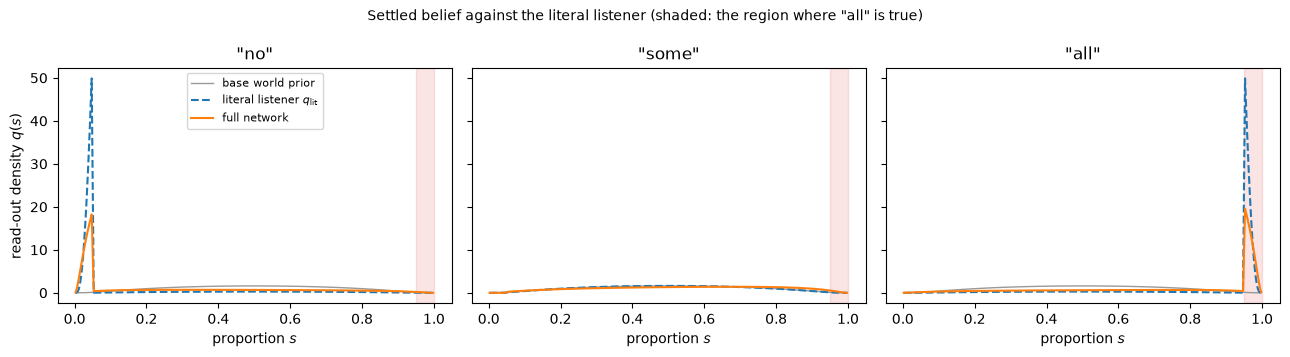

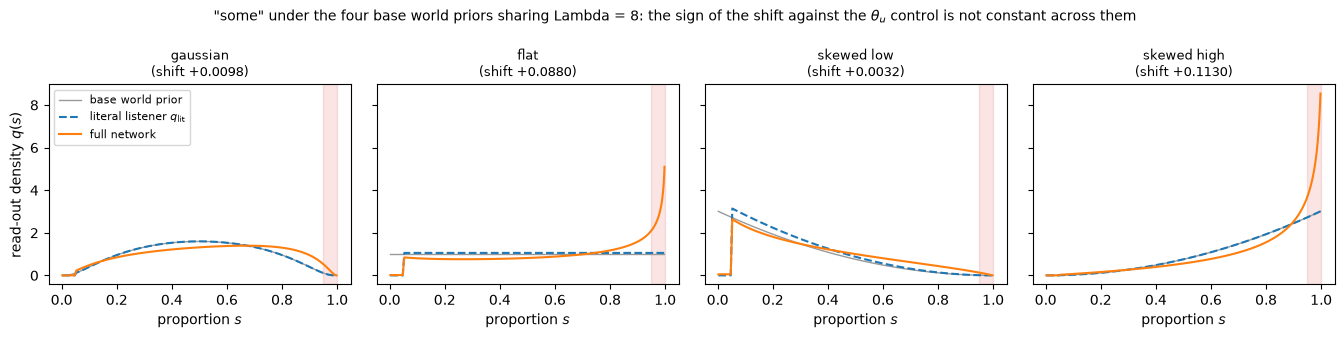

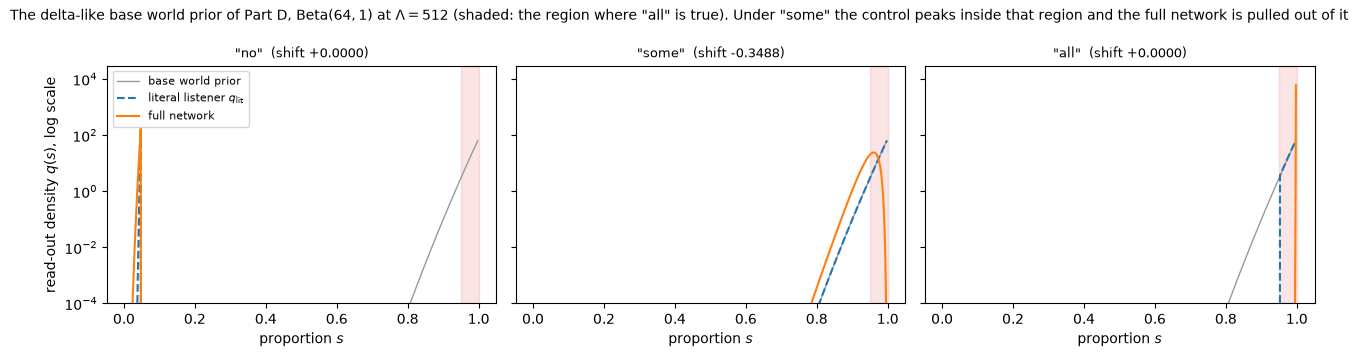

In [2]:
# === Code Cell E2: EVALUATION ===
#
# Code Cell 2 of main.ipynb with four checks added to Part A and nothing else
# changed. The four are Eq. (E4a) against Eq. (20)'s column form, the non-vacuity of
# m > 1, a lagged relay landing on the instantaneous fixed point, and the stability
# boundary of Eq. (E5). The other thirteen must report exactly what they reported in
# main.ipynb; Code Cell E3 checks that they do, by running this same sequence
# again with its output captured and diffing it against what main.ipynb stored.

# === Code Cell 2: EVALUATION, covering specification checks, demonstration,
#     and the semantic question ===
#
# Part A tests every claim the specification makes that is testable.
# Part B shows what the network does.
# Part C asks whether it produces a scalar implicature. Under the criterion Text
# cell 4 Part C adopts, it does; that cell states what the reading commits us to.

import math
import torch


# ============================================================================
# A. SPECIFICATION CHECKS
# ============================================================================

def check_specification(net, *, dt=0.02, seed=0, verbose=True):
    """Test each testable claim of the specification. Returns {claim: (ok, detail)}."""
    torch.manual_seed(seed)
    results = {}

    # Sec. 6 / Sec. 8.6: `infer` must reproduce the closed forms exactly, since the
    # model is linear-Gaussian while phi_L is clamped.
    worst_state = worst_utility = 0.0
    worst_identity_1 = worst_identity_2 = 0.0
    worst_monotone = math.inf
    worst_q_mass = 0.0
    for utterance in UTTERANCES:
        result = net.infer(utterance, dt=dt)
        if not result["converged"]:
            results["convergence"] = (False, f"{utterance} did not converge")
        phi_S_star, phi_u_star = net.closed_form_fixed_point(utterance)
        worst_state = max(worst_state, float((result["phi_S"] - phi_S_star).abs().max()))
        worst_utility = max(
            worst_utility, float((result["phi_u"] - phi_u_star).abs().max())
        )

        # Eq. (17): eps_S = -eps_L and eps_u = theta_u B^T W eps_S
        units = result["error_units"]
        worst_identity_1 = max(
            worst_identity_1, float((units["state"] + units["lexical"]).abs().max())
        )
        worst_identity_2 = max(
            worst_identity_2,
            float(
                (units["utility"] - net.theta_u * net.project(units["state"]))
                .abs()
                .max()
            ),
        )

        # Sec. 8.2: F is non-decreasing along the flow
        trace = [entry["free_energy"] for entry in result["history"]]
        worst_monotone = min(
            worst_monotone, min(trace[i + 1] - trace[i] for i in range(len(trace) - 1))
        )

        # Eq. (12): the read-out integrates to 1
        worst_q_mass = max(
            worst_q_mass, abs(float((net.weights * result["q"]).sum()) - 1.0)
        )

    results.setdefault("convergence", (True, "all three utterances settled"))
    results["fixed point matches Eqs. (15)-(16)"] = (
        max(worst_state, worst_utility) < 1e-8,
        f"max |phi - phi*| = {max(worst_state, worst_utility):.2e}",
    )
    results["Eq. (17) eps_S = -eps_L"] = (
        worst_identity_1 < 1e-8, f"max residual = {worst_identity_1:.2e}"
    )
    results["Eq. (17) eps_u = theta_u B^T W eps_S"] = (
        worst_identity_2 < 1e-8, f"max residual = {worst_identity_2:.2e}"
    )
    results["Sec. 8.2  F non-decreasing"] = (
        worst_monotone > -1e-9,
        f"min step = {worst_monotone:+.2e} (roundoff at the fixed point)",
    )
    results["Eq. (12) read-out normalized"] = (
        worst_q_mass < 1e-10, f"max |1 - q-mass| = {worst_q_mass:.2e}"
    )

    # Sec. 8.1/8.4: the Hessian is negative definite, and Sec. 8.1(ii) says so
    # for every theta_u and Lambda. Run at m = num_basis, so the form tested is
    # Eq. (22) of Sec. 8.4, which reduces to Eq. (21) at m = 1.
    worst_form = -math.inf
    for theta in [-50.0, -1.0, 0.0, 1.0, 50.0]:
        for _ in range(400):
            v = torch.randn(net.num_nodes, dtype=net.dtype)
            t = torch.randn(net.num_basis, dtype=net.dtype)
            scale = math.sqrt(float(v.pow(2).sum() + t.pow(2).sum()))
            worst_form = max(
                worst_form,
                float(net.hessian_quadratic_form(v / scale, t / scale, theta_u=theta)),
            )
    results["Eq. (22) Hessian negative definite"] = (
        worst_form < 0.0, f"max over unit directions = {worst_form:+.3e}"
    )

    # Sec. 8.1(iii): phi_L enters r_L additively and so shifts the maximizer without
    # touching the Hessian. The testable consequence is about the RELAXATION RATE, not
    # the step count: phi_L moves the fixed point, so different utterances start at
    # different distances from it and reach an absolute tolerance at different times.
    # What must agree is the asymptotic contraction factor, which is set by the
    # eigenvalues of the Hessian alone.
    contraction = {}
    for utterance in UTTERANCES:
        trace = [entry["max_derivative"] for entry in net.infer(utterance, dt=dt)["history"]]
        tail = trace[len(trace) // 2 : len(trace) - 5]          # asymptotic regime
        span = len(tail) - 1
        contraction[utterance] = (tail[-1] / tail[0]) ** (1.0 / span)
    rates = list(contraction.values())
    spread = max(rates) - min(rates)
    # tolerance reflects the precision of a contraction rate estimated by finite
    # differences off a discrete trace, not the sharpness of the claim: the rates
    # below agree to eight significant figures.
    results["Sec. 8.1(iii) relaxation rate independent of phi_L"] = (
        spread < 1e-6,
        "contraction/step " + ", ".join(f"{y}={r:.9f}" for y, r in contraction.items()),
    )

    # Sec. 7: the analytic messages are the gradients of Eq. (13). Checked against
    # central differences at an off-equilibrium point, which is where a sign error
    # would show.
    utterance = "some"
    phi_L = net.lexical_field(utterance)
    settled = net.infer(utterance, dt=dt)
    phi_S = settled["phi_S"] + 0.3 * torch.randn_like(settled["phi_S"])
    phi_u = settled["phi_u"] + 0.3 * torch.randn_like(settled["phi_u"])
    r_lexical, r_state, r_utility = net.residuals(phi_S, phi_u, phi_L)
    step = 1e-6

    analytic_s = -(r_state / net.sigma_state) - (r_lexical / net.sigma_lexical)
    worst_gradient = 0.0
    for k in range(0, net.num_nodes, 17):
        up, down = phi_S.clone(), phi_S.clone()
        up[k] += step
        down[k] -= step
        numeric = (
            float(net.free_energy(up, phi_u, phi_L))
            - float(net.free_energy(down, phi_u, phi_L))
        ) / (2 * step * float(net.weights[k]))
        worst_gradient = max(
            worst_gradient,
            abs(numeric - float(analytic_s[k])) / (abs(float(analytic_s[k])) + 1e-9),
        )

    analytic_u = -(r_utility / net.sigma_utility) + net.theta_u * net.project(
        r_state / net.sigma_state
    )
    for k in range(net.num_basis):
        up, down = phi_u.clone(), phi_u.clone()
        up[k] += step
        down[k] -= step
        numeric = (
            float(net.free_energy(phi_S, up, phi_L))
            - float(net.free_energy(phi_S, down, phi_L))
        ) / (2 * step)
        worst_gradient = max(
            worst_gradient,
            abs(numeric - float(analytic_u[k])) / (abs(float(analytic_u[k])) + 1e-9),
        )

    analytic_theta = float(net.dot(phi_u, net.project(r_state / net.sigma_state)))
    numeric_theta = (
        float(net.free_energy(phi_S, phi_u, phi_L, theta_u=net.theta_u + step))
        - float(net.free_energy(phi_S, phi_u, phi_L, theta_u=net.theta_u - step))
    ) / (2 * step)
    worst_gradient = max(
        worst_gradient,
        abs(numeric_theta - analytic_theta) / (abs(analytic_theta) + 1e-9),
    )
    results["Sec. 7 messages are gradients of Eq. (13)"] = (
        worst_gradient < 1e-4, f"max relative error = {worst_gradient:.2e}"
    )

    # Sec. 7 / Appendix B: the locality of Eq. (20) at m > 1. The gradient is now
    # written at the descending relay, <eps_S, r> with r = B phi_u, which pools across
    # the K terminals of the one r -> eps_S projection. The form it replaces,
    # sum_j phi_u,j <eps_S, b_j>, is the same number and pools instead across m
    # synapses on m different neurons, which is the sharing Bogacz's Sec. 5 rejects
    # for Sigma. The architecture changed; the arithmetic must not have, and the
    # m > 1 case being defended must not be vacuous.
    worst_relay_gradient = 0.0
    weakest_column = math.inf
    column_report = []
    for utterance in UTTERANCES:
        result = net.infer(utterance, dt=dt)
        relay_form = float(net.theta_u_gradient(result))
        columns = net.theta_u_gradient_columns(result)
        worst_relay_gradient = max(
            worst_relay_gradient, abs(relay_form - float(columns.sum()))
        )
        weakest_column = min(weakest_column, float(columns.abs().min()))
        column_report.append(
            utterance + "=[" + ", ".join(f"{float(c):+.3f}" for c in columns) + "]"
        )
    results["Eq. (20) relay form equals column form"] = (
        worst_relay_gradient < 1e-12,
        f"max |<eps_S,r> - sum_j phi_u,j <eps_S,b_j>| = {worst_relay_gradient:.2e}",
    )
    results["Sec. 7 every basis column carries Eq. (20)"] = (
        weakest_column > 1e-3,
        "phi_u,j <eps_S,b_j> per column: " + "; ".join(column_report),
    )

    # The relay's own dynamics, tau_r r' = B phi_u - r, have fixed point r = B phi_u
    # for every tau_r, so a lagged relay must settle exactly where the instantaneous
    # one does.
    worst_lagged = 0.0
    for utterance in UTTERANCES:
        instant = net.infer(utterance, dt=0.01)
        lagged = net.infer(utterance, dt=0.01, tau_relay=0.01)
        if not lagged["converged"]:
            worst_lagged = math.inf
        worst_lagged = max(
            worst_lagged,
            float((instant["phi_S"] - lagged["phi_S"]).abs().max()),
            float((instant["phi_u"] - lagged["phi_u"]).abs().max()),
            float((lagged["relay"] - net.relay(lagged["phi_u"])).abs().max()),
        )
    results["Sec. 7 a lagged relay settles where the instant one does"] = (
        worst_lagged < 1e-9, f"max |instantaneous - lagged| = {worst_lagged:.2e}"
    )

    # It must nonetheless be FAST, and this is a cost of the relay reading rather
    # than a free consequence of it. The relay is a third lag inside a loop whose
    # gain is theta_u^2: two lags are stable at every gain, three are not, and the
    # loop at the learned theta_u sits close enough to its margin that a slow relay
    # oscillates. Refining dt does not recover it; the instability is in the ODE.
    # infer's guard is the exact spectrum of that loop, so bisecting it reports the
    # boundary at no integration cost. The requirement tightens as theta_u^-2, which
    # extends the model's timescale ordering by a term at its fast end:
    #
    #     tau_relay << tau_error << tau_state << tau_theta.
    def relay_boundary(theta, lo=1e-6, hi=0.0999):
        """Largest tau_relay the spectral guard accepts at this theta_u."""
        def accepted(tau_relay):
            try:
                net.infer(
                    "some", dt=1e-6, max_steps=1, tau_relay=tau_relay, theta_u=theta
                )
                return True
            except ValueError:
                return False
        for _ in range(50):
            mid = math.sqrt(lo * hi)
            lo, hi = (mid, hi) if accepted(mid) else (lo, mid)
        return lo

    boundary = {theta: relay_boundary(theta) for theta in (-20.0, -28.4375, -40.0, -80.0)}
    scaled = [theta * theta * tau for theta, tau in boundary.items()]
    results["Sec. 7 the relay must be fast, tightening as theta_u^-2"] = (
        all(value > 1.0 for value in scaled)
        and max(scaled) < 1.03
        and scaled == sorted(scaled, reverse=True),
        "tau_crit "
        + ", ".join(f"{tau:.2e} at theta_u={theta:g}" for theta, tau in boundary.items())
        + "; theta_u^2 tau_crit -> 1 ("
        + ", ".join(f"{value:.4f}" for value in scaled) + ")",
    )

    # Sec. 1: the grid discretizes the integral, not the state, so the reported
    # belief must be stable under refinement. What that claims is CONVERGENCE in K,
    # which is a statement about the tail of the sequence, not about how close two
    # coarse grids happen to sit. Testing it as a 51-vs-401 gap against a fixed
    # tolerance tests the convergence RATE instead, and the rate here is set by
    # something the claim does not mention: chi_y is a step, and trapezoidal
    # quadrature on a discontinuous integrand converges at O(h) with the step's
    # position jittering against the nodes as K changes. The smooth mask of Sec. 9.2
    # is the control, being the same model with a continuous integrand, and is
    # reported beside it.
    def expectations(num_nodes, sharpness):
        probe = net.respawn(num_nodes=num_nodes, exclusion_sharpness=sharpness)
        return [
            float((probe.weights
                   * probe.read_out(probe.closed_form_fixed_point(y)[0])
                   * logistic(probe.zeta)).sum())
            for y in UTTERANCES
        ]

    ladder = [51, 101, 201, 401, 801]
    hard = {k: expectations(k, None) for k in ladder}
    smooth = {k: expectations(k, 0.1) for k in ladder}
    spread = max(abs(hard[401][i] - hard[51][i]) for i in range(len(UTTERANCES)))
    tail = max(abs(hard[801][i] - hard[401][i]) for i in range(len(UTTERANCES)))
    smooth_tail = max(abs(smooth[801][i] - smooth[401][i]) for i in range(len(UTTERANCES)))
    results["Sec. 1  K is an accuracy parameter"] = (
        tail < 5e-3,
        f"E[s] converging: |401-801| = {tail:.1e} (hard chi_y), {smooth_tail:.1e} "
        f"(smooth chi_y); coarse 51-401 spread {spread:.1e} is the O(h) step artefact",
    )

    # Sec. 8.5: F~(theta_u) = max_x F(x, theta_u) must have an interior stationary
    # point, which is exactly what mu_u = 0 destroys: there F~ climbs monotonically to
    # an asymptote and theta_u diverges. Located in closed form (Sec. 8.6), so this is
    # cheap; the dynamics are checked separately below.
    #
    # THE SEARCH MUST COVER BOTH SIGNS. theta_u is an unconstrained real parameter:
    # Bogacz's Eqs. (25) and (56) give a gradient and no domain, and his own solution
    # theta* = u / v_p takes whichever sign the data give. Eliminating phi_S and phi_u
    # analytically (Sec. 8.6) reduces the objective to
    #
    #     F~(theta) = const - ||theta mu_u - c||^2 / (2 (sigma_u theta^2 + S)),
    #         S = sigma_L + sigma_S,        c = B^T W (ell_0 - phi_L),
    #
    # whose stationarity condition is the quadratic
    #
    #     sigma_u <mu_u,c> theta^2 + (S ||mu_u||^2 - sigma_u ||c||^2) theta
    #                                                        - S <mu_u,c> = 0.
    #
    # Its roots have product -S / sigma_u < 0, so whenever <mu_u,c> != 0 there is
    # exactly ONE root of each sign; the maximizer is the one with sign(theta*) =
    # sign(<mu_u,c>) and the other root is a minimum. So the half-line to search is
    # read off dF~/dtheta at zero, which equals <mu_u,c> / S, a positive multiple of
    # the same inner product, rather than assumed. Bracketing on theta_u > 0 alone
    # is a restriction Bogacz does not impose, and under g_S = theta_u B phi_u (with
    # ell_0 in g_L, Eq. 9) the maximizer is negative, so such a bracket reports a
    # divergence that is an artefact of the bracket and not a property of the model.
    slow = net.respawn()
    lexical = {u: slow.lexical_field(u) for u in UTTERANCES}

    def reduced_energy(theta):
        return sum(
            float(slow.free_energy(
                *slow.closed_form_fixed_point(u, theta_u=theta), lexical[u], theta_u=theta))
            for u in UTTERANCES
        ) / len(UTTERANCES)

    def reduced_gradient(theta):
        total = 0.0
        for u in UTTERANCES:
            phi_S, phi_u = slow.closed_form_fixed_point(u, theta_u=theta)
            _, r_state, _ = slow.residuals(phi_S, phi_u, lexical[u], theta_u=theta)
            total += float(slow.dot(phi_u, slow.project(r_state / slow.sigma_state)))
        return total / len(UTTERANCES)

    ascent_at_zero = reduced_gradient(0.0)
    if ascent_at_zero == 0.0:
        raise RuntimeError(
            "dF~/dtheta_u = 0 at theta_u = 0, i.e. <mu_u, c> = 0: the quadratic above "
            "degenerates and no interior maximizer exists on either half-line"
        )
    sign = 1.0 if ascent_at_zero > 0 else -1.0

    low, high = 1e-3, 1e6                      # MAGNITUDES; the sign is fixed above
    for _ in range(120):                       # geometric bisection on the gradient
        mid = math.sqrt(low * high)
        if sign * reduced_gradient(sign * mid) > 0:
            low = mid
        else:
            high = mid
    theta_star = sign * math.sqrt(low * high)
    margin = reduced_energy(theta_star) - reduced_energy(sign * 1e8)
    interior = (
        reduced_energy(theta_star) > reduced_energy(0.5 * theta_star)
        and reduced_energy(theta_star) > reduced_energy(2.0 * theta_star)
        and margin > 0
    )
    results["Sec. 8.5  F~ has an interior maximum in theta_u"] = (
        interior and abs(reduced_gradient(theta_star)) < 1e-6,
        f"theta_u* = {theta_star:.4f}, |dF~/dtheta_u| = {abs(reduced_gradient(theta_star)):.1e}, "
        f"margin over the asymptote = {margin:+.4f}",
    )

    # and the flow of Eq. (20) must move toward it, with F monotone. It is started on
    # the half-line located above: gradient ascent cannot cross the minimum sitting at
    # the opposite-signed root, so a start of the wrong sign runs to the asymptote
    # correctly, and would be testing the initialization rather than the model.
    dynamic = net.respawn(theta_u=math.copysign(net.theta_u, sign))
    trace = dynamic.learn_theta_u(UTTERANCES, tau_theta=20.0, num_updates=25)
    energies = [entry["free_energy"] for entry in trace]
    worst_step = min(energies[i + 1] - energies[i] for i in range(len(energies) - 1))
    approaching = (
        abs(dynamic.theta_u - theta_star) < abs(trace[0]["theta_u"] - theta_star)
        and abs(trace[-1]["gradient"]) < abs(trace[0]["gradient"])
    )
    results["Sec. 8.5  Eq. (20) ascends toward it"] = (
        approaching and worst_step > -1e-9,
        f"theta_u {trace[0]['theta_u']:.3f} -> {dynamic.theta_u:.3f} (target {theta_star:.3f}), "
        f"|grad| {abs(trace[0]['gradient']):.3g} -> {abs(trace[-1]['gradient']):.3g}, "
        f"min dF step {worst_step:+.1e}",
    )

    # Sec. 9.2: a dense-scale (smooth) lexical field changes nothing structural.
    worst_dense = 0.0
    for sharpness in [0.5, 1.0, 2.0]:
        probe = net.respawn(exclusion_sharpness=sharpness)
        for y in UTTERANCES:
            result = probe.infer(y, dt=dt)
            phi_S_star, _ = probe.closed_form_fixed_point(y)
            worst_dense = max(
                worst_dense, float((result["phi_S"] - phi_S_star).abs().max())
            )
    results["Sec. 9.2 smooth lexical field is compatible"] = (
        worst_dense < 1e-8, f"max |phi_S - phi_S*| = {worst_dense:.2e}"
    )

    if verbose:
        width = max(len(k) for k in results)
        print("SPECIFICATION CHECKS")
        print("=" * (width + 46))
        for claim, (ok, detail) in results.items():
            print(f"  {'PASS' if ok else 'FAIL'}  {claim:<{width}}  {detail}")
        print("=" * (width + 46))
        failures = sum(1 for ok, _ in results.values() if not ok)
        print(f"  {len(results) - failures}/{len(results)} passed")
        print()

    return results


# ============================================================================
# B. DEMONSTRATION
# ============================================================================

def demonstrate(net, *, dt=0.02, verbose=True):
    """Run the network on each utterance and report the settled belief."""
    proportion = logistic(net.zeta)
    upper_region = (net.zeta > net.theta_L).to(net.dtype)
    lower_region = (net.zeta <= -net.theta_L).to(net.dtype)

    table = {}
    for utterance in UTTERANCES:
        result = net.infer(utterance, dt=dt)
        q = result["q"]
        excluded = exclusion_indicator(
            utterance, net.zeta, net.theta_L, sharpness=net.exclusion_sharpness
        )
        table[utterance] = {
            "q": q,
            "expected_s": float((net.weights * q * proportion).sum()),
            "leak": float((net.weights * q * excluded).sum()),
            "upper_q_mass": float((net.weights * q * upper_region).sum()),
            "lower_q_mass": float((net.weights * q * lower_region).sum()),
            "phi_u": result["phi_u"].tolist(),
            "steps": result["steps"],
            "free_energy": float(result["free_energy"]),
        }

    if verbose:
        print("DEMONSTRATION")
        print(f"  Lambda = {net.lexical_strength}, theta_u = {net.theta_u}, "
              f"mu_u = {net.mu_u.tolist()}, boundary = {net.theta_L}")
        print()
        print(f"  {'utterance':<10}{'E[s]':>9}{'P(s~0)':>10}{'P(s~1)':>10}"
              f"{'leak':>10}{'steps':>8}   phi_u (tilt, width)")
        for utterance, row in table.items():
            print(f"  {utterance:<10}{row['expected_s']:>9.4f}{row['lower_q_mass']:>10.4f}"
                  f"{row['upper_q_mass']:>10.4f}{row['leak']:>10.4f}{row['steps']:>8}"
                  f"   [{row['phi_u'][0]:+.3f}, {row['phi_u'][1]:+.3f}]")
        print()
        print("  'leak' is the q-mass over the region the entry excludes;")
        print("  it goes to zero as Lambda grows, which is the Eq. (15) limit of Sec. 6.")
        print()

    return table


def lexical_strength_sweep(net, strengths=(1, 2, 4, 8, 16, 32, 64), dt=0.02):
    """Sec. 6: a hard support constraint is the Lambda -> infinity
    limit of Eq. (15), not a separate assumption. Leak should fall monotonically to 0."""
    rows = []
    for strength in strengths:
        probe = net.respawn(lexical_strength=float(strength))
        leaks = []
        for utterance in UTTERANCES:
            q = probe.infer(utterance, dt=dt)["q"]
            excluded = exclusion_indicator(
                utterance, probe.zeta, probe.theta_L,
                sharpness=probe.exclusion_sharpness,
            )
            leaks.append(float((probe.weights * q * excluded).sum()))
        rows.append((float(strength), max(leaks)))

    print("LAMBDA -> INFINITY RECOVERS THE HARD MASK (Sec. 6)")
    print(f"  {'Lambda':>8}{'max leak':>12}")
    for strength, leak in rows:
        print(f"  {strength:>8.0f}{leak:>12.6f}")
    monotone = all(rows[i + 1][1] <= rows[i][1] + 1e-12 for i in range(len(rows) - 1))
    print(f"  monotone decreasing: {monotone};  leak at Lambda={rows[-1][0]:.0f} "
          f"is {rows[-1][1]:.2e}")
    print()
    return rows


# ============================================================================
# C. THE SEMANTIC QUESTION: IS THERE A SCALAR IMPLICATURE?
# ============================================================================

def scalar_implicature_probe(net, *, dt=0.02, verbose=True):
    """Compare the settled belief against the literal listener.

    The baseline is q_lit, the untempered literal posterior of
    `literal_fixed_point`: phi_S = ell_0 - phi_L, the world prior restricted by the
    lexical entry and nothing else. The shift is measured against it.

    The theta_u = 0 belief is reported beside it as a secondary control. It is the
    same literal posterior tempered by one half (see `literal_fixed_point`), so it
    holds the temperature of the full network fixed while severing the utility level;
    q_lit holds the definition fixed instead. The two differ, and Text cell 4 Part D
    states by how much.

    A scalar implicature for "some" would move q-mass AWAY from the region where
    "all" is true. The measured quantity is therefore the change in P(s in all-region)
    between the control and the full network, and an implicature requires it to be
    NEGATIVE.
    """
    upper_region = (net.zeta > net.theta_L).to(net.dtype)
    proportion = logistic(net.zeta)

    rows = {}
    for utterance in UTTERANCES:
        baseline = net.read_out(net.literal_fixed_point(utterance))
        tempered = net.infer(utterance, dt=dt, theta_u=0.0)["q"]
        full = net.infer(utterance, dt=dt)["q"]
        rows[utterance] = {
            "tempered_upper": float((net.weights * tempered * upper_region).sum()),
            "baseline_upper": float((net.weights * baseline * upper_region).sum()),
            "full_upper": float((net.weights * full * upper_region).sum()),
            "baseline_expected_s": float((net.weights * baseline * proportion).sum()),
            "full_expected_s": float((net.weights * full * proportion).sum()),
            "baseline_q": baseline,
            "full_q": full,
        }
        rows[utterance]["shift"] = (
            rows[utterance]["full_upper"] - rows[utterance]["baseline_upper"]
        )

    if verbose:
        print("SCALAR IMPLICATURE PROBE")
        print("  baseline: q_lit, the untempered literal posterior (phi_S = ell_0 - phi_L)")
        print("  also shown: the theta_u = 0 control, that posterior tempered by 1/2")
        print()
        print(f"  {'utterance':<10}{'E[s] base':>11}{'E[s] full':>11}"
              f"{'P(all) base':>13}{'P(all) full':>13}{'shift':>10}"
              f"{'P(all) th_u=0':>15}")
        for utterance, row in rows.items():
            print(f"  {utterance:<10}{row['baseline_expected_s']:>11.4f}"
                  f"{row['full_expected_s']:>11.4f}{row['baseline_upper']:>13.4f}"
                  f"{row['full_upper']:>13.4f}{row['shift']:>+10.4f}"
                  f"{row['tempered_upper']:>15.4f}")
        print()
        shift = rows["some"]["shift"]
        verdict = "met" if shift < 0 else "NOT met"
        print(f"  Under the criterion of Text cell 4 Part C, the criterion is {verdict}:")
        print(f"  for \"some\" the utility level moves q-mass "
              f"{'away from' if shift < 0 else 'TOWARD'} the "
              f"all-region by {abs(shift):.4f}.")
        print("  Whether the criterion is met is a measurement; what meeting it commits")
        print("  the model to is argued in Text cell 4 Part C, not here. Note that the")
        print("  same criterion is met by other utterances too (see the shift column")
        print("  above), and that its sign is prior-dependent (Part D).")
        print()

    return rows


def theta_u_learning_probe(net, *, tau_theta=20.0, num_updates=60):
    """Sec. 8.5: integrate Eq. (20), tau_theta * d(theta_u)/dt = dF/d(theta_u).

    There is no learning rate: tau_theta is a time constant of the same kind as
    tau_error and tau_state, and the model's one timescale ordering runs
    tau_error << tau_state << tau_theta. It sets the rate, not the fixed point.

    Requires <mu_u, sum_y c_y> != 0 (Appendix B); mu_u != 0 (Sec. 3) is necessary but
    not sufficient. Otherwise F~ has no stationary point and theta_u diverges, which
    is Bogacz's Eq. (25) at v_p = 0, not a departure from it.
    """
    net = net.respawn()
    # Start on the half-line that contains the maximizer. dF~/dtheta_u at theta_u = 0
    # is <mu_u, B^T W (ell_0 - phi_L)> / (sigma_L + sigma_S), whose sign is the sign of
    # theta_u* (Part A); ascent cannot cross the opposite-signed root, which is a
    # minimum. The magnitude of the start is left as configured.
    lexical = {u: net.lexical_field(u) for u in UTTERANCES}
    ascent_at_zero = 0.0
    for u in UTTERANCES:
        phi_S, phi_u = net.closed_form_fixed_point(u, theta_u=0.0)
        _, r_state, _ = net.residuals(phi_S, phi_u, lexical[u], theta_u=0.0)
        ascent_at_zero += float(net.dot(phi_u, net.project(r_state / net.sigma_state)))
    net.theta_u = math.copysign(net.theta_u, ascent_at_zero)

    initial = net.theta_u
    trace = net.learn_theta_u(UTTERANCES, tau_theta=tau_theta, num_updates=num_updates)
    energies = [entry["free_energy"] for entry in trace]
    monotone = all(
        energies[i + 1] >= energies[i] - 1e-9 for i in range(len(energies) - 1)
    )
    print("SLOW PARAMETER (Eq. 20, Sec. 8.5)")
    print(f"  mu_u = {net.mu_u.tolist()}  (must be nonzero)")
    print(f"  theta_u: {initial:.4f} -> {net.theta_u:.6f} over {num_updates} steps "
          f"at tau_theta = {tau_theta:g}")
    print(f"  F increased monotonically: {monotone}")
    print(f"  final dF/dtheta_u = {trace[-1]['gradient']:+.3e}"
          f"  ({'settled' if abs(trace[-1]['gradient']) < 1e-3 else 'still ascending'})")
    print("  The flow is slow near the optimum because F~ is shallow there; the target")
    print("  is the stationary point Part A locates in closed form, not this endpoint.")
    probe = scalar_implicature_probe(net, verbose=False)
    print(f"  implicature shift for \"some\" at the settled theta_u: "
          f"{probe['some']['shift']:+.4f}")
    print("  Ascending F moves theta_u TOWARD the criterion of Text cell 4 Part C, not")
    print("  away from it, and deepens the shift as it goes. Eq. (13) contains no term")
    print("  rewarding informativity, so this is not F pursuing the criterion: raising")
    print("  |theta_u| amplifies the span(B) component of (ell_0 - phi_L), and the sign")
    print("  of the shift is set by where those directions put mass relative to the")
    print("  all-region. The effect saturates in |theta_u| and is the same for either")
    print("  sign; it enters through theta_u^2. See `theta_u_dependence` below.")
    print()
    return net, trace



def theta_u_stationary_point(net):
    """theta_u* for this configuration, in closed form (Eq. B2 via Sec. 8.6)."""
    lexical = {u: net.lexical_field(u) for u in UTTERANCES}

    def gradient(theta):
        total = 0.0
        for u in UTTERANCES:
            phi_S, phi_u = net.closed_form_fixed_point(u, theta_u=theta)
            _, r_state, _ = net.residuals(phi_S, phi_u, lexical[u], theta_u=theta)
            total += float(net.dot(phi_u, net.project(r_state / net.sigma_state)))
        return total / len(UTTERANCES)

    at_zero = gradient(0.0)
    if at_zero == 0.0:
        raise RuntimeError("<mu_u, sum_y c_y> = 0: no interior maximizer (Appendix B)")
    sign = 1.0 if at_zero > 0 else -1.0
    low, high = 1e-3, 1e6
    for _ in range(120):
        middle = math.sqrt(low * high)
        if sign * gradient(sign * middle) > 0:
            low = middle
        else:
            high = middle
    return sign * math.sqrt(low * high)


def theta_u_dependence(net, *, verbose=True):
    """Every headline number in this cell, recomputed across theta_u.

    The rest of the evaluation is reported at theta_u = 1, which is neither the
    learned optimum nor even its sign: theta_u* is NEGATIVE here (Appendix B). This
    probe exists so that no conclusion rests on the pinned value without that being
    visible. Four columns: the control (theta_u = 0), the reported setting, its
    negation, and the stationary point the flow of Eq. (20) actually ascends to.

    The shift row is Eq. (37), against q_lit, exactly as everywhere else in the
    notebook; the control column therefore shows what the theta_u = 0 tempering does
    on its own rather than a column of zeros.

    Read it for two things. Which quantities depend on theta_u at all, and which of
    those depend on its SIGN: the utility level reaches phi_S through theta_u * B and
    the fixed point through theta_u^2 * G, so quantities dominated by the quadratic
    term are near-identical at +theta and -theta while the mu_u-carried linear term
    is what breaks the symmetry.
    """
    star = theta_u_stationary_point(net)
    settings = [("control (0)", 0.0), ("reported (1)", 1.0),
                ("negated (-1)", -1.0), ("stationary", star)]
    proportion = logistic(net.zeta)
    upper = (net.zeta > net.theta_L).to(net.dtype)

    table = {}
    for label, theta in settings:
        column = {}
        for y in UTTERANCES:
            field = net.closed_form_fixed_point(y, theta_u=theta)[0]
            belief = net.read_out(field)
            base = net.read_out(net.literal_fixed_point(y))
            excluded = exclusion_indicator(
                y, net.zeta, net.theta_L, sharpness=net.exclusion_sharpness
            )
            column[y] = {
                "expected_s": float((net.weights * belief * proportion).sum()),
                "upper": float((net.weights * belief * upper).sum()),
                "leak": float((net.weights * belief * excluded).sum()),
                "shift": float((net.weights * belief * upper).sum())
                         - float((net.weights * base * upper).sum()),
            }
        contrast = (net.closed_form_fixed_point("all", theta_u=theta)[0]
                    - net.closed_form_fixed_point("some", theta_u=theta)[0])
        column["contrast"] = float(net.squared_norm(contrast)) ** 0.5
        table[label] = column

    if verbose:
        print("THETA_U DEPENDENCE OF THE REPORTED QUANTITIES")
        print(f"  theta_u* = {star:.4f} (closed form, Appendix B); the rest of this cell")
        print(f"  reports theta_u = {net.theta_u:g}.")
        print()
        for name, key, fmt in [("E[s]", "expected_s", "{:>15.4f}"),
                               ("P(all-region)", "upper", "{:>15.4f}"),
                               ("shift vs q_lit (37)", "shift", "{:>+15.4f}"),
                               ("leak", "leak", "{:>15.2e}")]:
            print(f"  {name}")
            print(f"    {'utterance':<12}" + "".join(f"{lab:>15}" for lab, _ in settings))
            for y in UTTERANCES:
                print(f"    {y:<12}"
                      + "".join(fmt.format(table[lab][y][key]) for lab, _ in settings))
            print()
        print(f"    {'||contrast||':<12}"
              + "".join(f"{table[lab]['contrast']:>15.4f}" for lab, _ in settings))
        print("    (all - some, in the quadrature norm; it GROWS with |theta_u|, so the")
        print("     utility level does move contrasts, unlike mu_u and ell_0.)")
        print()
        symmetric = max(
            abs(table["reported (1)"][y][key] - table["negated (-1)"][y][key])
            for y in UTTERANCES for key in ("expected_s", "upper")
        )
        print(f"  theta_u = +1 against theta_u = -1: largest difference {symmetric:.4f}.")
        print("  That is not small, and it is worth knowing WHERE it is large. phi_u*")
        print("  carries a term linear in theta_u (through mu_u) and one quadratic in it")
        print("  (through G); only the linear one changes under theta_u -> -theta_u, and")
        print("  it is relatively largest when |theta_u| is of order 1:")
        print()
        print(f"    {'|theta_u|':>12}{'max dE[s]':>12}{'max dP(all)':>14}")
        for magnitude in (0.5, 1.0, 2.0, 5.0, 10.0, abs(star), 100.0):
            gaps = [[], []]
            for y in UTTERANCES:
                plus = net.read_out(net.closed_form_fixed_point(y, theta_u=magnitude)[0])
                minus = net.read_out(net.closed_form_fixed_point(y, theta_u=-magnitude)[0])
                gaps[0].append(abs(float((net.weights * plus * proportion).sum())
                                   - float((net.weights * minus * proportion).sum())))
                gaps[1].append(abs(float((net.weights * plus * upper).sum())
                                   - float((net.weights * minus * upper).sum())))
            print(f"    {magnitude:>12.4f}{max(gaps[0]):>12.4f}{max(gaps[1]):>14.4f}")
        print()
        print("  The sign therefore matters MOST at the value the rest of this cell is")
        print("  pinned to, and progressively less toward theta_u*, where the quadratic")
        print("  term dominates and the two signs converge. Numbers reported at")
        print("  theta_u = 1 are being read at close to the worst case for this.")
        print()

    return table, star



# ============================================================================
# D. BASE WORLD PRIOR
# ============================================================================

# The delta-like row. Part D's other four priors are all diffuse over the scale, so
# none of them puts the criterion under any pressure: hearing "some" under a prior
# that is already spread out, there is little all-region mass to move away from. The
# sharp case is the one worth testing, and it is the case Code Cell 4 is built around.
#
# A literal delta at s = 1 is not representable, since s lies in the OPEN interval, so
# zeta = logit(1) is off the grid and ell_0 = log p_0 would be -infinity almost
# everywhere. Beta(alpha, 1) is the limit family that approaches it (Text cell 6).
#
#   alpha = 64 puts the mode in zeta at log(alpha) = 4.16, well inside the all-region
#   (zeta > theta_L = 2.9444) and well clear of the grid ceiling, which Text cell 6
#   warns sets in above alpha ~ 300; it carries 95.7% of its prior mass in the
#   all-region and only 0.95% on the top node.
#
#   Lambda must then be raised to match, or the prior simply overrides the lexicon and
#   the sweep measures the override rather than the criterion. Eq. (41) puts the
#   override threshold at Lambda_crit ~ alpha * log(2n) = 64 * 2.9957 = 192. Taking
#   Lambda = 8 alpha = 512, about 2.7x that, drives every leak below 1e-70: the entry
#   holds against the prior, which is the precondition for the probe to mean anything.
DELTA_ALL_ALPHA = 64.0
DELTA_ALL_LAMBDA = 8.0 * DELTA_ALL_ALPHA          # = 512, about 2.7 x Lambda_crit


def base_prior_sweep(net, priors=None, *, dt=0.02, verbose=True):
    """Repeat the demonstration and the implicature probe under each base world prior.

    ell_0 is a fixed quantity (Sec. 3), so changing it moves the maximizer of Eq. (13)
    but touches nothing in Sec. 8: by Eq. (22) the Hessian does not involve ell_0 any
    more than it involves phi_L, so every convergence result holds unchanged and the
    closed forms stay exact. What the sweep tests is semantic, not numerical: whether
    the conclusion of Part C is an artefact of one prior.

    The flat condition is a literal Uniform(0, 1) over the proportion, not a
    low-precision Gaussian; see `uniform_world_prior` for why the two differ.

    A prior may be given either as a log-density or as a (log_density, overrides) pair,
    the overrides passed on to `respawn`. That is how the delta-like row carries its own
    Lambda: its whole point is a prior sharp enough to need one.
    """
    priors = priors or {
        **BASE_WORLD_PRIORS,
        "delta (all)": (
            beta_world_prior(DELTA_ALL_ALPHA, 1.0),
            {"lexical_strength": DELTA_ALL_LAMBDA},
        ),
    }
    proportion = logistic(net.zeta)
    upper_region = (net.zeta > net.theta_L).to(net.dtype)

    rows = {}
    for name, specification in priors.items():
        prior, overrides = (
            specification if isinstance(specification, tuple) else (specification, {})
        )
        probe = net.respawn(base_prior=prior, **overrides)
        prior_density = torch.exp(probe.base_log_prior)
        entry = {
            "description": probe.base_prior_description,
            "lexical_strength": probe.lexical_strength,
            "prior_expected_s": float((probe.weights * prior_density * proportion).sum()),
            "prior_upper_mass": float((probe.weights * prior_density * upper_region).sum()),
            "utterances": {},
            "network": probe,
        }
        for y in UTTERANCES:
            settled = probe.infer(y, dt=dt)
            baseline = probe.read_out(probe.literal_fixed_point(y))
            tempered = probe.infer(y, dt=dt, theta_u=0.0)["q"]
            full = settled["q"]
            excluded = exclusion_indicator(
                y, probe.zeta, probe.theta_L, sharpness=probe.exclusion_sharpness
            )
            entry["utterances"][y] = {
                "expected_s": float((probe.weights * full * proportion).sum()),
                "baseline_upper": float((probe.weights * baseline * upper_region).sum()),
                "tempered_upper": float((probe.weights * tempered * upper_region).sum()),
                "full_upper": float((probe.weights * full * upper_region).sum()),
                "leak": float((probe.weights * full * excluded).sum()),
                "converged": settled["converged"],
                "closed_form_error": float(
                    (settled["phi_S"] - probe.closed_form_fixed_point(y)[0]).abs().max()
                ),
                "baseline_q": baseline,
                "full_q": full,
            }
            entry["utterances"][y]["shift"] = (
                entry["utterances"][y]["full_upper"]
                - entry["utterances"][y]["baseline_upper"]
            )
        rows[name] = entry

    if verbose:
        print("BASE WORLD PRIOR SWEEP")
        print()
        print(f"  {'prior':<13}{'description':<43}{'Lambda':>8}{'E[s] prior':>11}"
              f"{'P0(all)':>9}{'  E[s] | no    some    all':<28}")
        for name, entry in rows.items():
            means = "  ".join(
                f"{entry['utterances'][y]['expected_s']:.3f}" for y in UTTERANCES
            )
            print(f"  {name:<13}{entry['description']:<43}{entry['lexical_strength']:>8.0f}"
                  f"{entry['prior_expected_s']:>11.4f}{entry['prior_upper_mass']:>9.4f}"
                  f"         {means}")
        print()
        print("  implicature shift, P(all-region) full minus q_lit, the literal listener")
        print("  (a scalar implicature for \"some\" requires a NEGATIVE shift)")
        print()
        print(f"  {'prior':<13}" + "".join(f"{y:>12}" for y in UTTERANCES)
              + f"{'max leak':>12}{'max |phi_S - phi_S*|':>24}")
        for name, entry in rows.items():
            shifts = "".join(
                f"{entry['utterances'][y]['shift']:>+12.4f}" for y in UTTERANCES
            )
            worst = max(entry["utterances"][y]["closed_form_error"] for y in UTTERANCES)
            leak = max(entry["utterances"][y]["leak"] for y in UTTERANCES)
            print(f"  {name:<13}{shifts}{leak:>12.1e}{worst:>24.1e}")
        print()
        signs = {name: entry["utterances"]["some"]["shift"] for name, entry in rows.items()}
        met = [name for name, value in signs.items() if value < 0]
        print(f"  Criterion met under {len(met)} of {len(signs)} priors: "
              + ", ".join(met) + ".")
        print("  The sign is therefore NOT a property of the model alone; it depends on")
        print("  the prior the model is run against, which is a fact about the criterion")
        print("  as much as about the model. Text cell 4 Part C reads this.")
        print()

        # === the delta-like row, and the headroom that makes it readable ===
        if "delta (all)" in rows:
            entry = rows["delta (all)"]
            print("  THE DELTA-LIKE ROW. This is the case the criterion is under the most")
            print("  pressure in: the prior already puts %.1f%% of its mass in the all-region,"
                  % (100 * entry["prior_upper_mass"]))
            print("  so the theta_u control, given \"some\", an entry that does NOT")
            print("  exclude the all-region, stays there. Leak stays below")
            print("  %.0e, so the lexicon is holding and the probe is measuring the utility"
                  % max(entry["utterances"][y]["leak"] for y in UTTERANCES))
            print("  level rather than the prior overriding the entry.")
            print()
            print(f"    {'utterance':<10}{'P(all) base':>13}{'P(all) full':>13}{'shift':>10}"
                  f"{'room to fall':>14}{'room to rise':>14}")
            for y in UTTERANCES:
                row = entry["utterances"][y]
                print(f"    {y:<10}{row['baseline_upper']:>13.6f}{row['full_upper']:>13.6f}"
                      f"{row['shift']:>+10.4f}{row['baseline_upper']:>14.2e}"
                      f"{1.0 - row['baseline_upper']:>14.2e}")
            print()
            print("  READ THE HEADROOM BEFORE THE SHIFTS. \"no\" has essentially no")
            print("  all-region mass to lose and \"all\" essentially none to gain, so their")
            print("  zeros are saturation, not restraint; only \"some\" is free to move in")
            print("  both directions, and it is the one that moves. What is NOT saturation")
            print("  is that \"all\" keeps its all-region mass while \"some\" sheds a third of")
            print("  its own: both had room to fall, and only one fell. That difference is")
            print("  the even-parity (width) coordinate of their lexical projections, which")
            print("  is the one place the two entries differ.")
            print()

    return rows


# ============================================================================
# RUN
# ============================================================================

evaluation_network = LexicalPredictiveCodingNetwork()

check_specification(evaluation_network)
demonstration = demonstrate(evaluation_network)
lexical_strength_sweep(evaluation_network)
implicature = scalar_implicature_probe(evaluation_network)
learned_network, theta_trace = theta_u_learning_probe(evaluation_network)
theta_table, theta_star_value = theta_u_dependence(evaluation_network)
prior_rows = base_prior_sweep(evaluation_network)


# ---- figure ----

try:
    import matplotlib.pyplot as plt

    proportion = logistic(evaluation_network.zeta).numpy()

    # Curves are plotted as densities in the PROPORTION s, so the belief, which is
    # normalized as a density in zeta, must be pushed through the change of variables
    #     p_s(s) = p_zeta(zeta) * |dzeta/ds| = q(zeta) / (s (1 - s)),
    # dividing by ds/dzeta rather than multiplying by it. The transform is checkable:
    # sum_k w_k * to_s_density(q)_k * (ds/dzeta)_k = 1 exactly, whereas multiplying by
    # the Jacobian gives ~0.035.
    ds_dzeta = proportion * (1.0 - proportion)

    def to_s_density(field):
        return field.numpy() / ds_dzeta

    all_region_start = float(logistic(torch.tensor(evaluation_network.theta_L)))

    figure, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
    for axis, utterance in zip(axes, UTTERANCES):
        row = implicature[utterance]
        axis.plot(proportion, to_s_density(torch.exp(evaluation_network.base_log_prior)),
                  color="0.6", linewidth=1.0, label="base world prior")
        axis.plot(proportion, to_s_density(row["baseline_q"]),
                  linestyle="--", label="literal listener $q_{\\mathrm{lit}}$")
        axis.plot(proportion, to_s_density(row["full_q"]), label="full network")
        axis.axvspan(all_region_start, 1.0, alpha=0.12, color="tab:red")
        axis.set_title(f'"{utterance}"')
        axis.set_xlabel("proportion $s$")
    axes[0].set_ylabel("read-out density $q(s)$")
    axes[0].legend(fontsize=8, loc="upper center")
    figure.suptitle(
        "Settled belief against the literal listener "
        "(shaded: the region where \"all\" is true)", fontsize=10)
    figure.tight_layout()
    plt.show()

    # second figure: "some" under each base world prior (Part D). Each panel carries its
    # own prior, so the gray line differs from panel to panel.
    #
    # Only rows sharing this network's Lambda are drawn. Panels on a shared y-axis have
    # to be comparable, and the delta-like row deliberately carries its own Lambda; it
    # is reported in the table and the headroom block above instead.
    comparable = {
        name: entry for name, entry in prior_rows.items()
        if entry["lexical_strength"] == evaluation_network.lexical_strength
    }
    prior_figure, prior_axes = plt.subplots(
        1, len(comparable), figsize=(3.4 * len(comparable), 3.4), sharey=True
    )
    for axis, (name, entry) in zip(prior_axes, comparable.items()):
        row = entry["utterances"]["some"]
        axis.plot(proportion, to_s_density(torch.exp(entry["network"].base_log_prior)),
                  color="0.6", linewidth=1.0, label="base world prior")
        axis.plot(proportion, to_s_density(row["baseline_q"]),
                  linestyle="--", label="literal listener $q_{\\mathrm{lit}}$")
        axis.plot(proportion, to_s_density(row["full_q"]), label="full network")
        axis.axvspan(all_region_start, 1.0, alpha=0.12, color="tab:red")
        axis.set_title(f"{name}\n(shift {row['shift']:+.4f})", fontsize=9)
        axis.set_xlabel("proportion $s$")
    prior_axes[0].set_ylabel("read-out density $q(s)$")
    prior_axes[0].legend(fontsize=8)
    prior_figure.suptitle(
        '"some" under the four base world priors sharing Lambda = %g: the sign of the '
        'shift against the $\\theta_u$ control is not constant across them'
        % evaluation_network.lexical_strength, fontsize=10)
    prior_figure.tight_layout()
    plt.show()

    # third figure: the delta-like row of Part D, which the second figure cannot show.
    # It carries its own Lambda (DELTA_ALL_LAMBDA, not the network's), so it cannot
    # share the panels above. This is the sharp prior the criterion is under most
    # pressure from, and the case Code Cell 3 is built around.
    #
    # The vertical axis is LOGARITHMIC, which a near-delta prior forces: the settled
    # densities span four orders of magnitude, peaking at 6.1e3 under "all" against
    # 2.4e1 under "some", so on a linear axis every panel but "all" is a flat line
    # under one spike. On a shared log axis all three curves are legible in all three
    # panels, and the comparison to read is the full network against its own theta_u
    # control WITHIN each panel.
    delta_entry = prior_rows["delta (all)"]
    delta_prior = torch.exp(delta_entry["network"].base_log_prior)

    delta_figure, delta_axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
    for axis, utterance in zip(delta_axes, UTTERANCES):
        row = delta_entry["utterances"][utterance]
        axis.plot(proportion, to_s_density(delta_prior),
                  color="0.6", linewidth=1.0, label="base world prior")
        axis.plot(proportion, to_s_density(row["baseline_q"]),
                  linestyle="--", label="literal listener $q_{\\mathrm{lit}}$")
        axis.plot(proportion, to_s_density(row["full_q"]), label="full network")
        axis.axvspan(all_region_start, 1.0, alpha=0.12, color="tab:red")
        axis.set_yscale("log")
        axis.set_ylim(1e-4, 3e4)
        axis.set_title(f'"{utterance}"  (shift {row["shift"]:+.4f})', fontsize=9)
        axis.set_xlabel("proportion $s$")
    delta_axes[0].set_ylabel("read-out density $q(s)$, log scale")
    delta_axes[0].legend(fontsize=8, loc="upper left")
    delta_figure.suptitle(
        "The delta-like base world prior of Part D, $\\mathrm{Beta}(%g,1)$ at "
        "$\\Lambda=%g$ (shaded: the region where \"all\" is true). Under "
        "\"some\" the control peaks inside that region and the full network is "
        "pulled out of it" % (DELTA_ALL_ALPHA, DELTA_ALL_LAMBDA), fontsize=10)
    delta_figure.tight_layout()
    plt.show()

except ImportError:
    print("matplotlib unavailable; skipping the figure")

In [3]:
# === Code Cell E3: the appendix's only claim, checked ===
#
# Every number Code Cell E2 printed must be a number main.ipynb already printed.
# That is checkable rather than assertable: main.ipynb stores the output of its
# own Code Cell 2, so run the same sequence again with stdout captured and compare the
# two texts line by line. Running it twice also shows the run is deterministic.
#
# Whitespace is normalized and rules of "=" are dropped, because the claim column is
# padded to the width of the longest claim and this appendix adds four longer ones.
# Nothing else is allowed to differ: the permitted changes are exactly the four
# inserted PASS lines and the pass count.

import contextlib
import difflib
import io
import json
import pathlib
import re

transcript = io.StringIO()
with contextlib.redirect_stdout(transcript):
    probe_network = LexicalPredictiveCodingNetwork()
    check_specification(probe_network)
    demonstrate(probe_network)
    lexical_strength_sweep(probe_network)
    scalar_implicature_probe(probe_network)
    theta_u_learning_probe(probe_network)
    theta_u_dependence(probe_network)
    base_prior_sweep(probe_network)


def normalize(text):
    """Line list, runs of spaces collapsed and separator rules dropped."""
    kept = []
    for line in text.splitlines():
        line = re.sub(r"\s+", " ", line).strip()
        if line and set(line) != {"="}:
            kept.append(line)
    return kept


BASELINE = pathlib.Path("main.ipynb")
if not BASELINE.exists():
    raise FileNotFoundError(
        "main.ipynb must sit beside this notebook: it is the recorded output "
        "this appendix is checked against."
    )

baseline_cell = next(
    cell for cell in json.load(BASELINE.open())["cells"]
    if cell["cell_type"] == "code"
    and "".join(cell["source"]).startswith("# === Code Cell 2")
)
baseline = normalize(
    "".join(
        "".join(output.get("text", []))
        for output in baseline_cell["outputs"]
        if output.get("output_type") == "stream"
    )
)
current = normalize(transcript.getvalue())

inserted, deleted, replaced = [], [], []
for tag, i1, i2, j1, j2 in difflib.SequenceMatcher(
    None, baseline, current, autojunk=False
).get_opcodes():
    if tag == "insert":
        inserted += current[j1:j2]
    elif tag == "delete":
        deleted += baseline[i1:i2]
    elif tag == "replace":
        replaced += list(zip(baseline[i1:i2], current[j1:j2]))

unchanged = len(baseline) - len(deleted) - len(replaced)

print("APPENDIX E vs main.ipynb, Code Cell 2 output")
print("=" * 78)
print(f"  lines recorded in main.ipynb   {len(baseline)}")
print(f"  lines identical                     {unchanged}")
print(f"  lines deleted                       {len(deleted)}")
print(f"  lines changed                       {len(replaced)}")
print(f"  lines inserted                      {len(inserted)}")
print("=" * 78)

if deleted:
    print()
    print("DELETED (must be empty):")
    for line in deleted:
        print("  -", line)

if replaced:
    print()
    print("CHANGED (must be the pass count and nothing else):")
    for before, after in replaced:
        print("  -", before)
        print("  +", after)

if inserted:
    print()
    print("INSERTED (must be the four checks the relay adds):")
    for line in inserted:
        print("  +", line)

expected_change = (
    len(replaced) == 1
    and replaced[0][0] == "13/13 passed"
    and replaced[0][1] == "17/17 passed"
)
verdict = (
    not deleted
    and expected_change
    and len(inserted) == 4
    and all(line.startswith("PASS") for line in inserted)
)

print()
print("=" * 78)
print(
    f"  {'PASS' if verdict else 'FAIL'}  the relay changes no reported quantity: "
    f"{unchanged} lines identical, {len(deleted)} deleted,"
)
print(
    f"        {len(replaced)} changed (the pass count), "
    f"{len(inserted)} inserted (the checks the relay adds)"
)
print("=" * 78)

if not verdict:
    raise AssertionError(
        "Appendix E must reproduce main.ipynb exactly apart from the four added "
        "checks and the pass count; see the report above."
    )


APPENDIX E vs main.ipynb, Code Cell 2 output
  lines recorded in main.ipynb   141
  lines identical                     140
  lines deleted                       0
  lines changed                       1
  lines inserted                      4

CHANGED (must be the pass count and nothing else):
  - 13/13 passed
  + 17/17 passed

INSERTED (must be the four checks the relay adds):
  + PASS Eq. (20) relay form equals column form max |<eps_S,r> - sum_j phi_u,j <eps_S,b_j>| = 1.78e-14
  + PASS Sec. 7 every basis column carries Eq. (20) phi_u,j <eps_S,b_j> per column: no=[+8.004, +16.647]; some=[+10.031, +63.045]; all=[+10.031, +16.647]
  + PASS Sec. 7 a lagged relay settles where the instant one does max |instantaneous - lagged| = 1.12e-12
  + PASS Sec. 7 the relay must be fast, tightening as theta_u^-2 tau_crit 2.56e-03 at theta_u=-20, 1.25e-03 at theta_u=-28.4375, 6.29e-04 at theta_u=-40, 1.56e-04 at theta_u=-80; theta_u^2 tau_crit -> 1 (1.0257, 1.0125, 1.0063, 1.0016)

  PASS  the relay 

## E.2 What the relay commits us to

**The relay is not Bogacz's §5 interneuron.** Bogacz
(2017) §5 introduces an inhibitory interneuron to remove a **matrix inverse**: he wants
$\varepsilon_i=\Sigma_i^{-1}(\varphi_i-g_i)$, and $\Sigma^{-1}_{u,1,1}$ depends on $\Sigma_{u,2,2}$,
so he re-sites $\Sigma$ on a forward synapse where $\Delta\Sigma_i=\alpha(\varepsilon_ie_i-1)$ is
literally pre times post (his Eqs. 59–63). Our problem contains no inverse. It is **weight
sharing**: one scalar gains $K\times m$ entries of $M=\theta_u B$, so its gradient wants products
from synapses on $m$ different neurons. What transfers is not his circuit but his move, which is to
put the quantity the rule needs into a single neuron's *activity* and let the rule read it off
locally. Eq. (E1) is that move applied to a sum rather than to an inverse.

**The obvious objection, and why it is not fatal.** One may say the nonlocality has been relabelled:
the sum over $j$ still happens, now in the relay's dendrite. But Bogacz's own statement of local computation
licenses exactly that: a neuron may compute from the activity of its input neurons and the weights
"associated with these inputs". Summing one's own afferents falls under that sentence; requiring
products formed at synapses on *other* neurons is what the companion sentence on local plasticity
forbids. The change is of kind, not of notation.
It is worth adding that Eq. (19) already obliged the pooled signals to exist as physical quantities
before any of this, so the relay is cheaper than it looks; Appendix B makes the same observation
about $\langle\varepsilon_S,b\rangle$.

**The weight-transport assumption gets smaller, not larger.** Eqs. (E2) and (E3) use the same
$\theta_u$ in both directions, and the descending $B$ against the ascending $B^{\mathsf T}W$. This
is the weight-transport problem (Grossberg, 1987), and predictive-coding models of this family
inherit it from Bogacz's own $\Theta$ and $\Theta^{\mathsf T}$ rather than acquiring it here. What
is new is the accounting. $B$ is anatomy and never changes, so its symmetry is a fixed structural
fact rather than a quantity two sites must keep in step; the only **plastic** parameter that must be
held equal in the two directions is one scalar. A network with $\theta_u$ promoted to a matrix
would have to transport $K\times m$ learned numbers. The scalar restriction, which is what cost us
locality at $m>1$ in the first place, buys back a far weaker version of the assumption that is
usually the harder one to defend (Lillicrap et al., 2016).

**The relay has an anatomical reading, and the two inputs are of different kinds.** $B$ is fixed and
sets what the relay represents; $\theta_u$ is plastic and sets only how strongly it is read. That is
the driver/modulator distinction of Sherman and Guillery (1998), and $\theta_u$ is a gain on a
projection rather than a content-bearing weight, which is the form multiplicative gain modulation
takes in cortex (Ferguson & Cardin, 2020). Eq. (E6) then says something with empirical content: the
stronger the $u\to S$ gain a network has learned, the faster its relay must be, on pain of
oscillation. A model whose $\theta_u$ grows without a correspondingly fast relay predicts ringing in
the $\varphi_u$ loop rather than convergence.

**What the relay does not buy.** It adds no representational capacity: $r$ is a deterministic
rank-$m$ image of $\varphi_u$, nothing is stored in it, and $\mathcal F$ does not see it. Exactly one
parameter remains plastic, and the loop remains one-dimensional. In particular Appendix B's
Alternatives section is untouched: there is still one synapse, one scalar and one pooled error
signal, so no two lexical entries are compared at any moment, and any implicature reaching the
belief through $\theta_u^\ast$ remains conventionalized rather than computed. The relay makes the
architecture local; it does not make it cleverer.

**Where this sits.** Whittington and Bogacz (2017) show that a predictive-coding network with
strictly local Hebbian plasticity approximates backpropagation, and the constraint they hold
themselves to is the one used here. Rao and Ballard (1999) is the ancestor of the architecture and
does not impose it. Millidge et al. (2021) survey how much of the framework survives when locality
is enforced rather than assumed. The stability argument behind Eq. (E5) is the standard
eigenvalue one; Bogacz makes it for his own interneuron by way of Strogatz (1994), and the fact that
a third lag can destabilize a loop two lags cannot is elementary feedback theory
(Åström & Murray, 2008).

## E.3 Claims in `main.ipynb`, restated

Cross-references are to `main.ipynb`. **Revised** means the sentence as written is superseded
by this appendix; **Reinforced** means it stands and is now better supported; **Unaffected** means
it is untouched and is listed only so the reader need not check.

### Revised

| Where | What it says there | Status |
|---|---|---|
| Text cell 3 §4, Eq. (10) | $g_S(\varphi_u)=\theta_u\varphi_u b$ | Replaced by Eq. (E2), $g_S=\theta_u r$. The map of $\varphi_u$ is the same; the factorization is not. |
| Text cell 3 §8.4 | the $m>1$ lift $g_S=\theta_u B\varphi_u$ | Replaced by Eqs. (E1)–(E2). $B$ now acts at the relay's afferents rather than inside the generative map. |
| Text cell 3 §7, Eq. (19) | $\tau_\varphi\dot\varphi_u=-\varepsilon_u+\theta_u\langle\varepsilon_S,b\rangle$ | Replaced by Eq. (E3). Identical at $m=1$. |
| Text cell 3 §7, Eq. (20) | $\tau_\theta\dot\theta_u=\varphi_u\langle\varepsilon_S,b\rangle$ | Replaced by Eq. (E4). Identical at $m=1$, and local at every $m$. |
| Text cell 3 §7 | "$\tau_\varepsilon\ll\tau_\varphi\ll\tau_\theta$" | Extended to Eq. (E6), $\tau_r\ll\tau_\varepsilon\ll\tau_\varphi\ll\tau_\theta$, with the separation scaling as $\theta_u^{-2}$. A new commitment, not a restatement. |
| Text cell 3 §7 | "The only departure from Eq. (25) is the contraction against $b$, forced by $\varphi_S$ being a field rather than a scalar." | The contraction is now against $r$ and runs over the terminals of one projection. The reason given, that $\varphi_S$ is a field, is unchanged and is now the *only* reason: at the relay, $m$ plays no part in it. |
| Text cell 3 §8.4, "The matrix case" | promoting $\theta_u$ to a matrix makes the $u\to S$ weights "$K\times m$ independently modifiable synapses, which is a different circuit" | Stands, restated at the relay: a matrix gain is $K\times K$ free synapses on the $r\to\varepsilon_S$ projection, and by § E.2 it would also need $K\times m$ learned numbers transported rather than one. Still a different circuit. |
| Appendix B, Locality | "Our $b$ extends that argument from two connections to $K$, on the same grounds." | Now extends it to the $K$ terminals of the relay projection, and the extension no longer depends on $m$. |

### Reinforced

| Where | What it says there | Why it is stronger here |
|---|---|---|
| Appendix B, Locality | "The ranking therefore inverts against expectation: Bogacz's full matrix is local, and it is our scalar restriction that needs defending." | Correct, and it was the open problem. Eq. (E4) is the defence, and § E.2 shows the scalar also buys a weaker weight-transport assumption than the matrix would. |
| Appendix B, Locality | the commitment that $b$ is "the fixed spatial profile of one connection … and *not* $K$ independently modifiable synapses sharing a gain" | This is the load-bearing commitment, and the relay is what makes it sufficient. It licenses pooling across $K$; Eq. (E1) reduces the $m$-fold sum to exactly that pooling, so nothing beyond it is assumed. |
| Appendix B, Locality | "Nothing extra is assumed for plasticity that inference did not already require." | Still true. Eq. (E3) obliges the pooled signals to exist for inference; Eq. (E4) reads one of them at one synapse. |
| Appendix B, Locality, "The price" | the matrix reading of §8.4 is foreclosed as a physical generalization | Unchanged, and now for a stated reason at every $m$ rather than at $m=1$. |
| Appendix B, Alternatives | "under the single-projection commitment above there is no anatomy in which such a comparison could take place: one synapse, one scalar, one pooled error signal" | Was true as stated only at $m=1$; it is now literally true at the $m=2$ the model runs at. The conventionalized-rather-than-computed position is unchanged and better founded. |
| Text cell 3 §8.4, "Why $B$ cannot matter" | Eq. (22) is negative definite for every $B$ and every $\theta_u$ | Unchanged, and the reason is sharper: the relay carries no residual, so it enters neither Eq. (13) nor the Hessian. Verified again here at 17/17. |
| Appendix C | $m=1$ is degenerate; an inventory needs $m>1$ | This is what made the gap worth closing. The locality claim in `main.ipynb` holds at $m=1$, and Appendix C is the reason $m=1$ is not where the model lives. |

### Unaffected

Text cell 3 §§1–3, 5, 6, 8.1–8.3, 8.5, 8.6, 9.1–9.3; Appendix A in full; Appendix B's
Eqs. (B1)–(B3), the standing condition $\langle\mu_u,\sum_y c_y\rangle\neq0$, the sign argument and
$\theta_u^\ast=-28.4375$; Appendix B's Alternatives section in full; Appendix C; Appendix D; Text
cells 4, 5 and 6 and every number in Code cells 9 and 10. Code Cell E3 checks the last of these
directly.

## References added in this appendix

APA 7th, continuing the reference list of `main.ipynb`. The entries there are not repeated;
Bogacz (2017) in particular is cited throughout above and is listed there.

---

Åström, K. J., & Murray, R. M. (2008). *Feedback systems: An introduction for scientists and
engineers*. Princeton University Press.

Ferguson, K. A., & Cardin, J. A. (2020). Mechanisms underlying gain modulation in the cortex.
*Nature Reviews Neuroscience, 21*(2), 80–92. https://doi.org/10.1038/s41583-019-0253-y

Grossberg, S. (1987). Competitive learning: From interactive activation to adaptive resonance.
*Cognitive Science, 11*(1), 23–63.

Lillicrap, T. P., Cownden, D., Tweed, D. B., & Akerman, C. J. (2016). Random synaptic feedback
weights support error backpropagation for deep learning. *Nature Communications, 7*, 13276.
https://doi.org/10.1038/ncomms13276

Millidge, B., Seth, A., & Buckley, C. L. (2021). *Predictive coding: A theoretical and experimental
review*. arXiv. https://doi.org/10.48550/arXiv.2107.12979

Rao, R. P. N., & Ballard, D. H. (1999). Predictive coding in the visual cortex: A functional
interpretation of some extra-classical receptive-field effects. *Nature Neuroscience, 2*(1), 79–87.
https://doi.org/10.1038/4580

Sherman, S. M., & Guillery, R. W. (1998). On the actions that one nerve cell can have on another:
Distinguishing "drivers" from "modulators". *Proceedings of the National Academy of Sciences,
95*(12), 7121–7126. https://doi.org/10.1073/pnas.95.12.7121

Strogatz, S. H. (1994). *Nonlinear dynamics and chaos: With applications to physics, biology,
chemistry, and engineering*. Addison-Wesley.

Whittington, J. C. R., & Bogacz, R. (2017). An approximation of the error backpropagation algorithm
in a predictive coding network with local Hebbian synaptic plasticity. *Neural Computation, 29*(5),
1229–1262. https://doi.org/10.1162/NECO_a_00949